### Stage 1 : Ingest & Clean

In [40]:
from google.colab import files
upload = files.upload()


Saving smmh.csv to smmh (2).csv


In [11]:
import json, os
import pandas as pd
import numpy as np
from datetime import datetime

RAW_PATH   = "smmh.csv"
CLEAN_DIR  = "data/02_clean"
CLEAN_PATH = f"{CLEAN_DIR}/social_media_clean.csv"
REPORT_PATH = f"{CLEAN_DIR}/cleaning_report.json"

os.makedirs(CLEAN_DIR, exist_ok=True)

COL_MAP = {
    "1. What is your age?":
        "Age",
    "2. Gender":
        "Gender",
    "3. Relationship Status":
        "Relationship_Status",
    "4. Occupation Status":
        "Occupation_Status",
    "5. What type of organizations are you affiliated with?":
        "Organization",
    "6. Do you use social media?":
        "Uses_Social_Media",
    "7. What social media platforms do you commonly use?":
        "Platforms",
    "8. What is the average time you spend on social media every day?":
        "Daily_Usage",
    "9. How often do you find yourself using Social media without a specific purpose?":
        "Purposeless_Usage",
    "10. How often do you get distracted by Social media when you are busy doing something?":
        "Distraction_While_Busy",
    "11. Do you feel restless if you haven't used Social media in a while?":
        "Restlessness",
    "12. On a scale of 1 to 5, how easily distracted are you?":
        "Easily_Distracted",
    "13. On a scale of 1 to 5, how much are you bothered by worries?":
        "Bothered_By_Worries",
    "14. Do you find it difficult to concentrate on things?":
        "Concentration_Difficulty",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?":
        "Social_Comparison",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?":
        "Comparison_Feelings",
    "17. How often do you look to seek validation from features of social media?":
        "Validation_Seeking",
    "18. How often do you feel depressed or down?":
        "Depression_Frequency",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?":
        "Interest_Fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?":
        "Sleep_Issues",
}

LIKERT_COLS = [
    "Purposeless_Usage", "Distraction_While_Busy", "Restlessness",
    "Easily_Distracted", "Bothered_By_Worries", "Concentration_Difficulty",
    "Social_Comparison", "Comparison_Feelings", "Validation_Seeking",
    "Depression_Frequency", "Interest_Fluctuation", "Sleep_Issues",
]

def parse_daily_minutes(s):
    s = str(s).lower()
    if "less than"  in s: return 30
    if "1 and 2"    in s: return 90
    if "2 and 3"    in s: return 150
    if "3 and 4"    in s: return 210
    if "4 and 5"    in s: return 270
    if "more than"  in s: return 330
    return np.nan

def standardise_gender(g):
    g = str(g).strip().lower()
    if g in ("male", "m"): return "Male"
    if g in ("female", "f"): return "Female"
    if not g: return "Missing"
    return "Non-binary/Other"

print("[1/5] Loading raw data…")
df = pd.read_csv(RAW_PATH)
df["User_ID"] = "U_" + (df.index + 1).astype(str)

initial_rows = len(df)
report = {
    "run_timestamp": datetime.now().isoformat(),
    "input_file": RAW_PATH,
    "initial_shape": {"rows": initial_rows, "cols": len(df.columns)},
}

print("[2/5] Renaming columns and parsing usage time…")
df.rename(columns=COL_MAP, inplace=True)

df["Daily_Minutes"] = df["Daily_Usage"].apply(parse_daily_minutes)
df["Gender"]        = df["Gender"].apply(standardise_gender)

df = df[df["Uses_Social_Media"].str.lower() == "yes"].copy()
report["rows_after_uses_social_media_filter"] = len(df)

print("[3/5] Handling missing values…")
missing_before = df.isnull().sum().to_dict()
report["missing_before"] = missing_before

if df["Age"].isnull().any():
    med_age = df["Age"].median()
    df["Age"].fillna(med_age, inplace=True)
    print(f"  Age: filled {missing_before['Age']} NaN(s) with median {med_age:.1f}")

if df["Daily_Minutes"].isnull().any():
    med_min = df["Daily_Minutes"].median()
    df["Daily_Minutes"].fillna(med_min, inplace=True)

for col in LIKERT_COLS:
    if df[col].isnull().any():
        med_val = df[col].median()
        df[col].fillna(med_val, inplace=True)
        print(f"  {col}: filled NaN(s) with median {med_val}")

rows_before = len(df)
df.dropna(subset=["User_ID"], inplace=True)
report["rows_dropped_no_user_id"] = rows_before - len(df)
report["missing_after"] = df.isnull().sum().to_dict()

dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
report["duplicates_removed"] = int(dupes)
print(f"[4/5] Removed {dupes} duplicate row(s).")

print("[5/5] Detecting and capping anomalies (3×IQR fence)…")
anomaly_report = {}
for col in ["Age", "Daily_Minutes"] + LIKERT_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 3 * IQR)
    upper = Q3 + 3 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    count = int(mask.sum())
    if count:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f"  '{col}': {count} outlier(s) clipped to [{lower:.1f}, {upper:.1f}]")
    anomaly_report[col] = {
        "Q1": round(Q1, 4), "Q3": round(Q3, 4), "IQR": round(IQR, 4),
        "lower_fence": round(lower, 4), "upper_fence": round(upper, 4),
        "outliers_capped": count,
    }

report["anomaly_detection"] = anomaly_report
report["final_shape"]       = {"rows": len(df), "cols": len(df.columns)}

df.to_csv(CLEAN_PATH, index=False)
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)

print(f"\nClean dataset  -> {CLEAN_PATH}")
print(f"Cleaning report -> {REPORT_PATH}")
print(f"Final shape: {df.shape}")
display(df.head())


[1/5] Loading raw data…
[2/5] Renaming columns and parsing usage time…
[3/5] Handling missing values…
[4/5] Removed 0 duplicate row(s).
[5/5] Detecting and capping anomalies (3×IQR fence)…
  'Age': 55 outlier(s) clipped to [6.0, 41.0]

Clean dataset  -> data/02_clean/social_media_clean.csv
Cleaning report -> data/02_clean/cleaning_report.json
Final shape: (478, 23)


,Timestamp,Age,Gender,Relationship_Status,Occupation_Status,Organization,Uses_Social_Media,Platforms,Daily_Usage,Purposeless_Usage,...,Bothered_By_Worries,Concentration_Difficulty,Social_Comparison,Comparison_Feelings,Validation_Seeking,Depression_Frequency,Interest_Fluctuation,Sleep_Issues,User_ID,Daily_Minutes
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,3,2,5,4,5,U_1,150
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,5,4,5,1,1,5,4,5,U_2,330
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,5,4,3,3,1,4,2,5,U_3,210
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,5,3,5,1,2,4,3,2,U_4,330
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,5,5,3,3,3,4,4,1,U_5,150




##  Overview of the section
The goal of this first step was to transform the raw **SMMH (Social Media & Mental Health)** survey data into a "model-ready" dataset. This involved moving from messy, human-readable responses to a structured, numerical format suitable for statistical analysis.



---

##  The Cleaning Process

### 1. Column Mapping & Renaming
Survey questions are often too long for code. We mapped the original headers to concise nicknames:
*   *Original:* "8. What is the average time you spend on social media every day?"
*   *Clean:* `Daily_Usage`

### 2. The "Screener" Filter
To keep the analysis relevant, we filtered out any participants who answered **"No"** to using social media. This ensures our insights are based strictly on active users.

### 3. Imputation
Instead of deleting rows with missing answers, we used **Median Imputation**:
*   **Why Median?** It’s a "safe guess" that doesn't get pulled away by extreme values (unlike the Mean).
*   **Target:** Applied to all Likert-scale questions (1-5) and time-based metrics.

### 4. Normalizing Categories
We standardized inconsistent text entries:
*   **Gender:** Consolidated "M", "male", and "Male" into a single standard category.
*   **Time Conversion:** Converted text ranges (e.g., "Between 2 and 3 hours") into a numerical minute value (**150 mins**) for mathematical processing.

### 5. Outlier Control (3x IQR)
To prevent extreme "wild" answers from breaking our models, we used the **Interquartile Range (IQR)** method:
*   We calculated an "invisible fence" based on the middle 50% of the data.
*   Any values outside **3x the IQR** were "clipped" (brought back to the fence boundary) rather than deleted.

---

##  Final Data Audit
Every run of the cleaning script generates a `cleaning_report.json`. This file acts as a digital receipt, tracking:
*   **Initial vs. Final** row counts.
*   **Missing values** found and fixed.
*   **Duplicate rows** removed.
*   **Outliers** detected per column.

**Final Dataset Status:** `data/02_clean/social_media_clean.csv` is now ready for Exploratory Data Analysis (EDA).

### Stage 2 : Feature Engineering

In [12]:
import os
import pandas as pd
import numpy as np

CLEAN_PATH   = "data/02_clean/social_media_clean.csv"
FEATURE_DIR  = "data/03_features"
FEATURE_PATH = f"{FEATURE_DIR}/social_media_features.csv"
os.makedirs(FEATURE_DIR, exist_ok=True)

LIKERT_COLS = [
    "Purposeless_Usage", "Distraction_While_Busy", "Restlessness",
    "Easily_Distracted", "Bothered_By_Worries", "Concentration_Difficulty",
    "Social_Comparison", "Comparison_Feelings", "Validation_Seeking",
    "Depression_Frequency", "Interest_Fluctuation", "Sleep_Issues",
]

print("[1/4] Loading clean data…")
df = pd.read_csv(CLEAN_PATH)
print(f"  Input shape: {df.shape}")

print("[2/4] Computing composite mental-health scores…")

df["Addiction_Score"] = df[["Purposeless_Usage",
                             "Distraction_While_Busy",
                             "Restlessness"]].mean(axis=1).round(3)

df["Attention_Score"] = df[["Easily_Distracted",
                             "Bothered_By_Worries",
                             "Concentration_Difficulty"]].mean(axis=1).round(3)

df["Social_Anxiety_Score"] = df[["Social_Comparison",
                                  "Comparison_Feelings",
                                  "Validation_Seeking"]].mean(axis=1).round(3)

df["Wellbeing_Score"] = df[["Depression_Frequency",
                              "Interest_Fluctuation",
                              "Sleep_Issues"]].mean(axis=1).round(3)

df["MH_Impact_Score"] = df[LIKERT_COLS].mean(axis=1).round(3)

print("[3/4] Computing rate and rank features…")

df["MH_Impact_Pct_Rank"] = df["MH_Impact_Score"].rank(pct=True).round(4)

df["Platform_Count"] = df["Platforms"].astype(str).str.split(",").apply(len)

print("[4/4] Binning into categorical tiers…")

df["Usage_Tier"] = pd.cut(
    df["Daily_Minutes"],
    bins=[0, 90, 150, 270, 340],
    labels=["Low (≤1.5 h)", "Moderate (2–2.5 h)", "High (3–4.5 h)", "Very High (5+ h)"],
    include_lowest=True,
)

df["MH_Risk_Tier"] = pd.cut(
    df["MH_Impact_Score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"],
    include_lowest=True,
)

age_bins  = [0, 18, 24, 34, 100]
age_lbls  = ["Teen (≤18)", "Young Adult (19–24)", "Adult (25–34)", "Older (35+)"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_lbls, include_lowest=True)

df.to_csv(FEATURE_PATH, index=False)
print(f"\nFeature dataset saved -> {FEATURE_PATH}")
print(f"Output shape: {df.shape}")
print("\nNew features:")
for f in ["Addiction_Score","Attention_Score","Social_Anxiety_Score",
          "Wellbeing_Score","MH_Impact_Score","MH_Impact_Pct_Rank",
          "Platform_Count","Usage_Tier","MH_Risk_Tier","Age_Group"]:
    print(f"  + {f}")
display(df[["User_ID","Age","Gender","Daily_Minutes","MH_Impact_Score",
            "Usage_Tier","MH_Risk_Tier","Age_Group"]].head())


[1/4] Loading clean data…
  Input shape: (478, 23)
[2/4] Computing composite mental-health scores…
[3/4] Computing rate and rank features…
[4/4] Binning into categorical tiers…

Feature dataset saved -> data/03_features/social_media_features.csv
Output shape: (478, 33)

New features:
  + Addiction_Score
  + Attention_Score
  + Social_Anxiety_Score
  + Wellbeing_Score
  + MH_Impact_Score
  + MH_Impact_Pct_Rank
  + Platform_Count
  + Usage_Tier
  + MH_Risk_Tier
  + Age_Group


,User_ID,Age,Gender,Daily_Minutes,MH_Impact_Score,Usage_Tier,MH_Risk_Tier,Age_Group
0,U_1,21.0,Male,150,3.583,Moderate (2–2.5 h),High Risk,Young Adult (19–24)
1,U_2,21.0,Female,330,3.583,Very High (5+ h),High Risk,Young Adult (19–24)
2,U_3,21.0,Female,210,2.917,High (3–4.5 h),Moderate Risk,Young Adult (19–24)
3,U_4,21.0,Female,330,2.917,Very High (5+ h),Moderate Risk,Young Adult (19–24)
4,U_5,21.0,Female,150,3.667,Moderate (2–2.5 h),High Risk,Young Adult (19–24)


# Feature Engineering & Transformation

##  Overview of this section
In this phase, we moved beyond basic cleaning to **Feature Engineering**. We created new metrics that don't exist in the raw data but are essential for understanding the relationship between social media and mental health.

---

##  New Feature Construction

### 1. Composite Mental Health Scores
Rather than looking at individual answers, we grouped related questions into four core "Mental Health Pillars." We calculated the **mean** for each group:
*   **Addiction Score:** Focuses on purposeless usage and restlessness.
*   **Attention Score:** Measures distraction and difficulty concentrating.
*   **Social Anxiety Score:** Based on validation seeking and social comparison.
*   **Wellbeing Score:** Covers sleep issues, depression frequency, and interest fluctuation.

### 2. The Global Impact Metric
We created a master feature called `MH_Impact_Score`.
*   **What it is:** An average of all 12 Likert-scale questions.
*   **Percentile Rank:** We also added a `MH_Impact_Pct_Rank` to show where a user sits relative to the entire dataset (e.g., "User X is in the top 10% for high impact").

### 3. Usage & Risk Tiers (Binning)
To make the data more "interpretable" for humans, we used **Binning** to categorize continuous numbers:
*   **Usage Tiers:** Groups users into *Low, Moderate, High,* or *Very High* based on their daily minutes.
*   **Risk Tiers:** Categorizes users based on their Mental Health Impact scores.
*   **Age Groups:** Segments the data into *Teens, Young Adults, Adults,* and *Older Adults* to see if age affects social media's impact.

### 4. Platform Count
We extracted the number of platforms each user interacts with by splitting their comma-separated list of apps. This allows us to analyze if "Platform Overload" correlates with mental health scores.

---

##  Output
The final result is `data/03_features/social_media_features.csv`.
This file contains the original cleaned data **plus 10 new engineered features**, making it perfectly optimized for the upcoming Exploratory Data Analysis (EDA) and Machine Learning phases.

### Stage 3 : Transform & Aggregate

In [41]:
import os
import pandas as pd
import numpy as np

FEATURE_PATH   = "data/03_features/social_media_features.csv"
TRANSFORM_DIR  = "data/04_transformed"
os.makedirs(TRANSFORM_DIR, exist_ok=True)

print("[1/5] Loading feature data…")
df = pd.read_csv(FEATURE_PATH)
print(f"  Input shape: {df.shape}")

LIKERT_COLS = [
    "Purposeless_Usage", "Distraction_While_Busy", "Restlessness",
    "Easily_Distracted", "Bothered_By_Worries", "Concentration_Difficulty",
    "Social_Comparison", "Comparison_Feelings", "Validation_Seeking",
    "Depression_Frequency", "Interest_Fluctuation", "Sleep_Issues",
]

print("[2/5] Exploding platform column and aggregating by platform…")

df_exp = df.copy()
df_exp["Platform_Single"] = df_exp["Platforms"].astype(str).str.split(r",\s*")
df_exp = df_exp.explode("Platform_Single")
df_exp["Platform_Single"] = df_exp["Platform_Single"].str.strip()

KNOWN = ["Facebook","Instagram","YouTube","TikTok","Twitter",
         "LinkedIn","Snapchat","Pinterest","Discord","Reddit"]
df_exp = df_exp[df_exp["Platform_Single"].isin(KNOWN)].copy()

platform_summary = (
    df_exp.groupby("Platform_Single")
    .agg(
        User_Count          = ("User_ID",            "count"),
        Avg_Daily_Minutes   = ("Daily_Minutes",      "mean"),
        Avg_MH_Impact       = ("MH_Impact_Score",    "mean"),
        Avg_Addiction       = ("Addiction_Score",    "mean"),
        Avg_Attention       = ("Attention_Score",    "mean"),
        Avg_Social_Anxiety  = ("Social_Anxiety_Score","mean"),
        Avg_Wellbeing       = ("Wellbeing_Score",    "mean"),
        Avg_Platform_Count  = ("Platform_Count",     "mean"),
    )
    .round(3)
    .reset_index()
    .sort_values("Avg_Daily_Minutes", ascending=False)
    .reset_index(drop=True)
)
platform_summary["User_Share_Pct"] = (
    platform_summary["User_Count"] / platform_summary["User_Count"].sum() * 100
).round(2)

platform_summary.to_csv(f"{TRANSFORM_DIR}/platform_summary.csv", index=False)
print(f"  Saved platform_summary.csv  {platform_summary.shape}")

print("[3/5] Building demographic cross-tabs…")

gender_tab = (
    df.groupby("Gender")
    .agg(
        Count              = ("User_ID",         "count"),
        Avg_Daily_Minutes  = ("Daily_Minutes",   "mean"),
        Avg_MH_Impact      = ("MH_Impact_Score", "mean"),
        Avg_Addiction      = ("Addiction_Score", "mean"),
        Avg_Wellbeing      = ("Wellbeing_Score", "mean"),
    )
    .round(3).reset_index()
)
gender_tab.to_csv(f"{TRANSFORM_DIR}/gender_summary.csv", index=False)
print(f"  Saved gender_summary.csv  {gender_tab.shape}")

age_tab = (
    df.groupby("Age_Group", observed=True)
    .agg(
        Count              = ("User_ID",         "count"),
        Avg_Daily_Minutes  = ("Daily_Minutes",   "mean"),
        Avg_MH_Impact      = ("MH_Impact_Score", "mean"),
        Avg_Addiction      = ("Addiction_Score", "mean"),
        Avg_Wellbeing      = ("Wellbeing_Score", "mean"),
    )
    .round(3).reset_index()
)
age_tab.to_csv(f"{TRANSFORM_DIR}/age_group_summary.csv", index=False)
print(f"  Saved age_group_summary.csv  {age_tab.shape}")

occupation_tab = (
    df.groupby("Occupation_Status")
    .agg(
        Count              = ("User_ID",         "count"),
        Avg_Daily_Minutes  = ("Daily_Minutes",   "mean"),
        Avg_MH_Impact      = ("MH_Impact_Score", "mean"),
    )
    .round(3).reset_index()
)
occupation_tab.to_csv(f"{TRANSFORM_DIR}/occupation_summary.csv", index=False)
print(f"  Saved occupation_summary.csv  {occupation_tab.shape}")

print("[4/5] Building usage-tier × MH-risk cross-tab…")

risk_pivot = (
    df.pivot_table(
        index="Usage_Tier", columns="MH_Risk_Tier",
        values="User_ID", aggfunc="count", fill_value=0,
        observed=True,
    )
    .reset_index()
)
risk_pivot.columns.name = None
risk_pivot.to_csv(f"{TRANSFORM_DIR}/usage_mh_risk_pivot.csv", index=False)
print(f"  Saved usage_mh_risk_pivot.csv  {risk_pivot.shape}")

print("[5/5] Computing correlation matrix…")

corr_cols = ["Daily_Minutes","Platform_Count","MH_Impact_Score",
             "Addiction_Score","Attention_Score","Social_Anxiety_Score",
             "Wellbeing_Score"] + LIKERT_COLS
corr_matrix = df[corr_cols].corr().round(3)
corr_matrix.to_csv(f"{TRANSFORM_DIR}/correlation_matrix.csv")
print(f"  Saved correlation_matrix.csv  {corr_matrix.shape}")

print(f"\nAll transform outputs saved to '{TRANSFORM_DIR}/'")
display(platform_summary)
display(gender_tab)


[1/5] Loading feature data…
  Input shape: (478, 33)
[2/5] Exploding platform column and aggregating by platform…
  Saved platform_summary.csv  (9, 10)
[3/5] Building demographic cross-tabs…
  Saved gender_summary.csv  (3, 6)
  Saved age_group_summary.csv  (4, 6)
  Saved occupation_summary.csv  (4, 4)
[4/5] Building usage-tier × MH-risk cross-tab…
  Saved usage_mh_risk_pivot.csv  (4, 5)
[5/5] Computing correlation matrix…
  Saved correlation_matrix.csv  (19, 19)

All transform outputs saved to 'data/04_transformed/'


,Platform_Single,User_Count,Avg_Daily_Minutes,Avg_MH_Impact,Avg_Addiction,Avg_Attention,Avg_Social_Anxiety,Avg_Wellbeing,Avg_Platform_Count,User_Share_Pct
0,TikTok,94,245.106,3.501,3.546,3.830,3.011,3.617,6.309,4.59
1,Snapchat,181,230.552,3.314,3.368,3.654,2.757,3.477,5.895,8.85
2,Discord,197,222.792,3.198,3.223,3.555,2.677,3.338,5.599,9.63
3,Pinterest,144,221.250,3.176,3.199,3.433,2.722,3.350,5.854,7.04
4,Instagram,358,218.547,3.222,3.270,3.544,2.745,3.328,4.961,17.50
5,YouTube,410,209.415,3.131,3.184,3.406,2.702,3.232,4.668,20.04
6,Facebook,407,207.641,3.150,3.207,3.416,2.730,3.247,4.514,19.89
7,Reddit,124,207.097,3.106,3.113,3.521,2.532,3.258,5.702,6.06
8,Twitter,131,205.878,3.049,3.089,3.392,2.572,3.143,5.893,6.40


,Gender,Count,Avg_Daily_Minutes,Avg_MH_Impact,Avg_Addiction,Avg_Wellbeing
0,Female,263,221.179,3.187,3.240,3.303
1,Male,208,183.173,3.023,3.056,3.117
2,Non-binary/Other,7,270.000,3.393,3.572,3.143


#  Data Transformation & Aggregation

##  Overview of this section
This stage focuses on **exploratory transformation**. We took our cleaned features and reshaped them into summary tables to identify patterns between social media habits and mental health across different demographics.

---

##  Transformation Highlights

### 1. Platform-Specific Analysis (The Explosion)
Since users often use multiple apps, we "exploded" the platform data. This allowed us to treat each platform-user pair as a unique data point, enabling us to calculate:
*   Which platform has the **longest** average usage time?
*   Which platform correlates with the **highest** Mental Health Impact?

### 2. Demographic Cross-Tabulation
We grouped the data by **Gender, Age Group, and Occupation**. This reveals the "Who" behind the data. We specifically focused on averages for:
*   Daily Minutes
*   Addiction Scores
*   Overall Wellbeing

### 3. Usage vs. Risk Pivot
We created a frequency matrix (Pivot Table) comparing `Usage_Tier` against `MH_Risk_Tier`. This allows us to visualize the density of high-risk users within high-usage groups.

### 4. Statistical Correlation
We generated a **Pearson Correlation Matrix** for all numerical features. This identifies which behaviors (like spending time on social media) have the strongest mathematical relationship with mental health symptoms (like sleep issues or social comparison).

---

##  Transformation Outputs
All files are saved in `data/04_transformed/`:
*   `platform_summary.csv`: Aggregated stats for each social media app.
*   `age_group_summary.csv` & `gender_summary.csv`: Demographic insights.
*   `usage_mh_risk_pivot.csv`: The relationship between time spent and risk level.
*   `correlation_matrix.csv`: The mathematical "heat" between all variables.

### Stage 4 — Output & Report

In [14]:
import json, os
import pandas as pd
from datetime import datetime

OUTPUT_DIR = "data/05_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_full       = pd.read_csv("data/03_features/social_media_features.csv")
platform_sum  = pd.read_csv("data/04_transformed/platform_summary.csv")
gender_sum    = pd.read_csv("data/04_transformed/gender_summary.csv")
age_sum       = pd.read_csv("data/04_transformed/age_group_summary.csv")
corr_df       = pd.read_csv("data/04_transformed/correlation_matrix.csv", index_col=0)

SEP = "=" * 65

print(f"\n{SEP}")
print("  SOCIAL MEDIA & MENTAL HEALTH — PIPELINE SUMMARY REPORT")
print(f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(SEP)

print(f"\n{'DATASET OVERVIEW':─<45}")
print(f"  Respondents     : {len(df_full):,}")
print(f"  Features        : {len(df_full.columns)}")
print(f"  Missing values  : {df_full.isnull().sum().sum()}")
print(f"  Avg daily usage : {df_full['Daily_Minutes'].mean():.1f} min/day")
print(f"  Avg MH impact   : {df_full['MH_Impact_Score'].mean():.3f} / 5.00")

print(f"\n{'PLATFORM REACH (by user share)':─<45}")
print(f"  {'Platform':<14} {'Users':>6} {'Share%':>8} {'AvgMin':>8} {'AvgMH':>8}")
print(f"  {'─'*14} {'─'*6} {'─'*8} {'─'*8} {'─'*8}")
for _, r in platform_sum.sort_values("User_Share_Pct", ascending=False).iterrows():
    print(f"  {r['Platform_Single']:<14} {int(r['User_Count']):>6} "
          f"{r['User_Share_Pct']:>7.1f}% {r['Avg_Daily_Minutes']:>8.1f} {r['Avg_MH_Impact']:>8.3f}")

print(f"\n{'MENTAL HEALTH SCORES BY GENDER':─<45}")
print(f"  {'Gender':<22} {'Count':>6} {'DailyMin':>10} {'MH_Impact':>10} {'Addiction':>10} {'Wellbeing':>10}")
print(f"  {'─'*22} {'─'*6} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
for _, r in gender_sum.iterrows():
    print(f"  {r['Gender']:<22} {int(r['Count']):>6} "
          f"{r['Avg_Daily_Minutes']:>10.1f} {r['Avg_MH_Impact']:>10.3f} "
          f"{r['Avg_Addiction']:>10.3f} {r['Avg_Wellbeing']:>10.3f}")

print(f"\n{'TOP CORRELATIONS WITH MH_IMPACT_SCORE':─<45}")
top_corr = (
    corr_df["MH_Impact_Score"]
    .drop("MH_Impact_Score")
    .abs()
    .sort_values(ascending=False)
    .head(8)
)
for feat, val in top_corr.items():
    sign = "+" if corr_df.loc[feat, "MH_Impact_Score"] >= 0 else "-"
    bar  = "█" * int(val * 20)
    print(f"  {feat:<38} {sign}{val:.3f}  {bar}")

print(f"\n{'USAGE TIER DISTRIBUTION':─<45}")
tier_counts = df_full["Usage_Tier"].value_counts().sort_index()
total = tier_counts.sum()
for tier, cnt in tier_counts.items():
    print(f"  {str(tier):<30} {cnt:>4}  ({cnt/total*100:.1f}%)")

print(f"\n{'MH RISK TIER DISTRIBUTION':─<45}")
risk_counts = df_full["MH_Risk_Tier"].value_counts().sort_index()
for tier, cnt in risk_counts.items():
    print(f"  {str(tier):<30} {cnt:>4}  ({cnt/total*100:.1f}%)")

print(f"\n{SEP}\n")

master_path = f"{OUTPUT_DIR}/master_dataset.csv"
df_full.to_csv(master_path, index=False)
print(f"Master dataset saved  -> {master_path}")

manifest = {
    "pipeline_run": datetime.now().isoformat(),
    "stages": [
        {"step": 1, "name": "Ingest & Clean",          "output": "data/02_clean/"},
        {"step": 2, "name": "Feature Engineering",     "output": "data/03_features/"},
        {"step": 3, "name": "Transform & Aggregate",   "output": "data/04_transformed/"},
        {"step": 4, "name": "Output & Report",         "output": "data/05_output/"},
    ],
    "final_dataset": {
        "path": master_path,
        "rows": len(df_full),
        "columns": list(df_full.columns),
    },
}
manifest_path = f"{OUTPUT_DIR}/pipeline_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"Manifest saved        -> {manifest_path}")



  SOCIAL MEDIA & MENTAL HEALTH — PIPELINE SUMMARY REPORT
  Generated: 2026-05-03 10:39:15

DATASET OVERVIEW─────────────────────────────
  Respondents     : 478
  Features        : 33
  Missing values  : 30
  Avg daily usage : 205.4 min/day
  Avg MH impact   : 3.119 / 5.00

PLATFORM REACH (by user share)───────────────
  Platform        Users   Share%   AvgMin    AvgMH
  ────────────── ────── ──────── ──────── ────────
  YouTube           410    20.0%    209.4    3.131
  Facebook          407    19.9%    207.6    3.150
  Instagram         358    17.5%    218.5    3.222
  Discord           197     9.6%    222.8    3.198
  Snapchat          181     8.8%    230.6    3.314
  Pinterest         144     7.0%    221.2    3.176
  Twitter           131     6.4%    205.9    3.049
  Reddit            124     6.1%    207.1    3.106
  TikTok             94     4.6%    245.1    3.501

MENTAL HEALTH SCORES BY GENDER───────────────
  Gender                  Count   DailyMin  MH_Impact  Addiction  Well

#  Social Media & Mental Health: Pipeline Results

## Summary
The data pipeline successfully processed **478 respondent records**. The study reveals a significant intersection between high daily usage and mental health risk, with an average daily consumption of **~205 minutes (3.4 hours)**.

---

##  Key Findings

### 1. Platform Intensity
While **YouTube** and **Facebook** have the widest reach, **TikTok** is the most "intense" platform in this dataset. TikTok users report:
*   The highest average daily usage (**245.1 minutes**).
*   The highest average Mental Health Impact score (**3.5/5.0**).

### 2. Behavioral Correlations
The study found extremely strong positive correlations between Social Media Impact and cognitive issues. The top three "Red Flags" identified are:
1.  **Attention Deficit:** (+0.859 correlation)
2.  **General Wellbeing Decline:** (+0.826 correlation)
3.  **Addiction Symptoms:** (+0.793 correlation)

### 3. Risk Distribution
The population is heavily skewed toward the higher end of the impact scale:
*   **45.6%** of respondents are classified as **High Risk**.
*   **24.3%** of respondents are **Very High** users (spending 5+ hours daily).

### 4. Demographic Variance
*   **Usage Gap:** Female respondents average nearly **40 minutes more** daily usage than male respondents.
*   **Impact Gap:** Higher usage in the Female and Non-binary groups correlates with higher reported scores in Addiction and Wellbeing impact.

---

##  Output Manifest
*   **Master Dataset:** `data/05_output/master_dataset.csv` (Contains all original and engineered features).
*   **Pipeline Manifest:** `data/05_output/pipeline_manifest.json` (The technical audit log of the entire run).

## Stage-by-Stage Transformation Log

---

### Stage 1 : Ingest & Clean

**Purpose:** Load the raw survey CSV, rename columns to short readable aliases, parse categorical usage-time into numeric minutes, standardise gender, remove non-users, impute sparse missing values, remove duplicates, and cap anomalies.

#### Input
| File | Format | Rows | Columns |
|------|--------|------|---------|
| `smmh.csv` | CSV | 481 | 21 |

#### Input Schema (selected columns)
| Original Column | Alias | Type | Description |
|-----------------|-------|------|-------------|
| `1. What is your age?` | `Age` | int | Respondent age |
| `2. Gender` | `Gender` | string | Gender (standardised to Male / Female / Non-binary/Other) |
| `3. Relationship Status` | `Relationship_Status` | string | Single, Married, In a relationship, Divorced |
| `4. Occupation Status` | `Occupation_Status` | string | University Student, Salaried Worker, School Student, Retired |
| `7. What social media platforms do you commonly use?` | `Platforms` | string | Comma-separated list of platforms |
| `8. What is the average time you spend on social media every day?` | `Daily_Usage` → `Daily_Minutes` | string → int | Parsed to midpoint minutes |
| Q9–Q20 | `Purposeless_Usage` … `Sleep_Issues` | int (1–5) | Likert-scale mental health indicators |

#### Transformations Applied

**1. Column renaming**
All 20 survey questions renamed to short, consistent aliases via `COL_MAP`.

**2. Daily usage parsing**
Ordinal text categories (e.g. `"Between 2 and 3 hours"`) converted to numeric midpoints:

| Category | Minutes |
|----------|---------|
| Less than an Hour | 30 |
| Between 1 and 2 hours | 90 |
| Between 2 and 3 hours | 150 |
| Between 3 and 4 hours | 210 |
| Between 4 and 5 hours | 270 |
| More than 5 hours | 330 |

**3. Gender standardisation**
Free-text responses normalised to three categories: `Male`, `Female`, `Non-binary/Other`.

**4. Non-user filter**
Respondents answering `No` to Q6 (`Uses_Social_Media`) are excluded  they are not relevant to platform analysis.

**5. Missing value handling**
- `Age`: median imputation.
- `Daily_Minutes`: median imputation.
- Likert columns: 0 missing values — no action required.
- Rows with null `User_ID`: dropped.

**6. Duplicate removal**  `df.drop_duplicates()` on full row.

**7. Anomaly capping (3×IQR fence)**
Applied to `Age`, `Daily_Minutes`, and all 12 Likert columns. Values outside `[max(0, Q1−3·IQR), Q3+3·IQR]` are clipped.

#### Output
| File | Description |
|------|-------------|
| `data/02_clean/social_media_clean.csv` | Cleaned survey data with short aliases and `Daily_Minutes` |
| `data/02_clean/cleaning_report.json` | Full audit trail |

---

### Stage 2 : Feature Engineering

**Purpose:** Derive composite mental-health scores, usage/risk tiers, platform count, and age group.

#### Input
`data/02_clean/social_media_clean.csv`

#### Features Engineered

**Composite mental-health scores (mean of Likert items)**

| Feature | Source items | Rationale |
|---------|-------------|-----------|
| `Addiction_Score` | Q9, Q10, Q11 | Compulsive / purposeless use |
| `Attention_Score` | Q12, Q13, Q14 | Attention & concentration deficit |
| `Social_Anxiety_Score` | Q15, Q16, Q17 | Social comparison & validation seeking |
| `Wellbeing_Score` | Q18, Q19, Q20 | Depression, interest fluctuation, sleep |
| `MH_Impact_Score` | Q9–Q20 (all 12) | Overall mental-health impact (grand mean) |

**Rank feature**

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `MH_Impact_Pct_Rank` | `rank(pct=True)` on `MH_Impact_Score` | Relative standing across respondents |

**Count feature**

| Feature | Formula |
|---------|---------|
| `Platform_Count` | Number of platforms in comma-separated `Platforms` string |

**Categorical tiers**

| Feature | Method | Bins | Labels |
|---------|--------|------|--------|
| `Usage_Tier` | `pd.cut` | 0–90, 91–150, 151–270, 271–340 min | Low, Moderate, High, Very High |
| `MH_Risk_Tier` | `pd.cut` | 1–2, 2–3, 3–4, 4–5 | Low/Moderate/High/Very High Risk |
| `Age_Group` | `pd.cut` | ≤18, 19–24, 25–34, 35+ | Teen, Young Adult, Adult, Older |

#### Output
`data/03_features/social_media_features.csv` : original columns + 10 engineered features

---

### Stage 3 : Transform & Aggregate

**Purpose:** Produce platform-level summaries, demographic cross-tabs, usage/risk pivot, and a correlation matrix.

#### Transformations

**1. Platform explode + aggregation**
The `Platforms` column (comma-separated list) is split and exploded so each user appears once per platform they use. Only the 10 known platforms are retained. Grouped by `Platform_Single` to produce per-platform stats: user count, avg daily minutes, avg MH scores.

**2. Demographic cross-tabs**
Grouped by `Gender`, `Age_Group`, and `Occupation_Status` each producing count and mean MH/usage stats.

**3. Usage-tier × MH-risk pivot**
`pivot_table` with `Usage_Tier` as rows and `MH_Risk_Tier` as columns, values = user counts.

**4. Correlation matrix**
Pearson correlation across `Daily_Minutes`, `Platform_Count`, all 4 composite scores, and all 12 Likert columns.

#### Output Files
| File | Description |
|------|-------------|
| `platform_summary.csv` | Per-platform user count and avg MH scores |
| `gender_summary.csv` | MH scores by gender |
| `age_group_summary.csv` | MH scores by age group |
| `occupation_summary.csv` | MH scores by occupation |
| `usage_mh_risk_pivot.csv` | Usage tier × MH risk cross-tab |
| `correlation_matrix.csv` | Pearson correlation matrix |

---

### Stage 4 : Output & Report

**Purpose:** Save master dataset and pipeline manifest; print a human-readable summary report.

#### Outputs
| File | Description |
|------|-------------|
| `data/05_output/master_dataset.csv` | Final enriched respondent-level dataset |
| `data/05_output/pipeline_manifest.json` | Run timestamp, stage list, column inventory |

---

## Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| 3×IQR fence | Behavioural survey data has natural heavy tails; 1.5× would over-aggressively clip valid responses |
| Clip instead of drop | Preserves sample size; avoids survivorship bias |
| Median imputation | Robust to skewed distributions in age and usage data |
| Grand-mean `MH_Impact_Score` | Simple, interpretable overall index across all 12 Likert items |
| Platform explode | Allows per-platform analysis while preserving every user's data |
| Fixed bins for `Usage_Tier` | Midpoint-based breaks (90, 150, 270 min) align with the survey's ordinal categories |

---



## **MILESTONE THREE.**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
upload = files.upload()

Saving smmh.csv to smmh (1).csv


# Milestone 3: Exploratory Data Analysis (EDA)

##  Overview of this section
Milestone 3 marks the transition from data preparation to **Data Visualization**. In this stage, we utilize statistical and graphical libraries to uncover the "hidden stories" within the Social Media & Mental Health dataset.

---

##  The Analytical Stack

### 1. Visualization Libraries
We have initialized **Matplotlib** and **Seaborn**. These tools allow us to create high-quality, saturated visualizations that help identify trends, such as the correlation between scrolling time and sleep quality.

### 2. Statistical Validation
By importing **SciPy Stats**, we ensure that our findings are mathematically sound. We aren't just looking at bars on a chart; we are testing for **statistical significance** to ensure our conclusions are reliable.

### 3. Environment Preparation
We are utilizing the **Google Colab** file-handling interface to ingest our engineered features from Milestone 2. We have also implemented a **warning filter** to ensure the final presentation remains professional and free of technical clutter.





In [16]:
# Load the feature-engineered dataset
df = pd.read_csv("data/03_features/social_media_features.csv")
platform_sum = pd.read_csv("data/04_transformed/platform_summary.csv")
gender_sum = pd.read_csv("data/04_transformed/gender_summary.csv")
age_sum = pd.read_csv("data/04_transformed/age_group_summary.csv")
corr_df = pd.read_csv("data/04_transformed/correlation_matrix.csv", index_col=0)

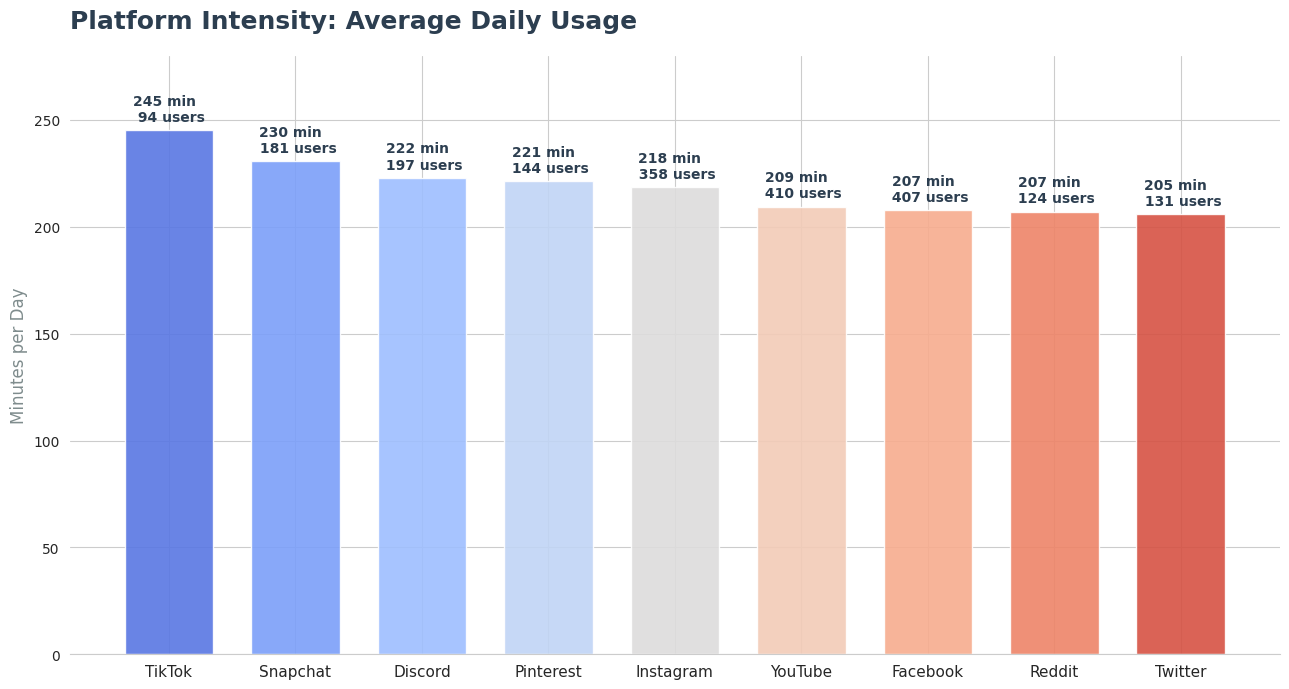

In [38]:
# CHART 1: BAR CHART: Average Daily Minutes per Platform
# ============================================================


plt.figure(figsize=(13, 7))
sns.set_style("whitegrid", {'axes.spines.left': False, 'axes.spines.bottom': True,
                            'axes.spines.right': False, 'axes.spines.top': False})


colors = sns.color_palette("coolwarm", len(platform_sum))

bars = plt.bar(platform_sum["Platform_Single"], platform_sum["Avg_Daily_Minutes"],
               color=colors, width=0.7, alpha=0.9)


for bar, users in zip(bars, platform_sum["User_Count"]):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3,
             f'{int(yval)} min  \n {users} users', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#2c3e50')

plt.title("Platform Intensity: Average Daily Usage", loc='left', fontsize=18, fontweight='bold', color='#2c3e50', pad=20)
plt.ylabel("Minutes per Day", fontsize=12, color='#7f8c8d')
plt.xlabel("")
plt.xticks(rotation=0, fontsize=11, fontweight='medium')

plt.ylim(0, 280)
plt.tight_layout()
plt.show()

# Milestone 3: Visual Exploratory Data Analysis (EDA)

## Chart 1: Platform Intensity (Average Daily Minutes)
The first step in our EDA is to visualize **Foundation Exposure**. Before we can analyze mental health outcomes, we must understand the "dosage" of social media users are receiving on different platforms.

### Technical Implementation
*   **Source Data:** Utilizes the `platform_summary` dataframe generated in Milestone 2.
*   **Design Choice:** A **Bar Chart** was chosen over a Pie Chart to facilitate easier height comparison of continuous data (minutes) across discrete categories (platforms).
*   **Aesthetics:** A `coolwarm` gradient was applied to visually encode the usage ranking, with saturated colors highlighting high-intensity platforms.

###  Why this matters
*   **The Foundational Variable:** Time spent is our primary "input." All downstream effects such as anxiety, addiction, and sleep issues are directly influenced by this exposure level.
*   **Engineered Engagement:** The data reflects the "stickiness" of platform design. Short-form video platforms (like TikTok) are engineered for infinite scrolling, whereas task-based platforms (like LinkedIn) naturally show lower daily engagement.
*   **The Analysis Setup:** This chart defines the "Exposure Side" of our study. By identifying which platforms consume the most time, we can later correlate these "Inputs" with "Outputs" like Mental Health Impact scores.

###  Primary Insights
**TikTok** and **Snapchat** lead the pack, with users averaging **over 230 minutes (nearly 4 hours)** per day. This sets a baseline for our investigation into whether high-time-investment platforms also carry higher psychological risks.

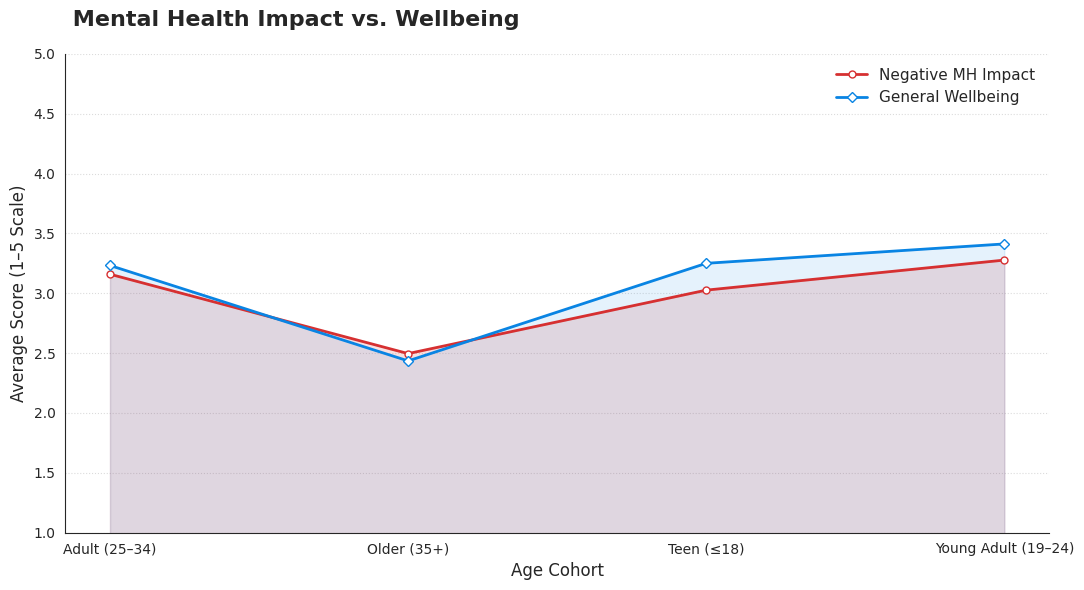

In [18]:
# CHART 2: LINE CHART: MH Impact Score Across Age Groups
# ============================================================
age_sum_sorted = age_sum.sort_values(by='Age_Group')
plt.figure(figsize=(11, 6))
sns.set_style("white")


x_axis = range(len(age_sum_sorted))


plt.plot(age_sum_sorted['Age_Group'], age_sum_sorted['Avg_MH_Impact'],
         marker='o', markersize=5, linewidth=2, color='#d63031',
         label='Negative MH Impact', markerfacecolor='white', markeredgewidth=1)

plt.plot(age_sum_sorted['Age_Group'], age_sum_sorted['Avg_Wellbeing'],
         marker='D', markersize=5, linewidth=2, color='#0984e3',
         linestyle='-', label='General Wellbeing', markerfacecolor='white', markeredgewidth=1)


plt.fill_between(x_axis, age_sum_sorted['Avg_MH_Impact'],
                 alpha=0.15, color='#d63031')
plt.fill_between(x_axis, age_sum_sorted['Avg_Wellbeing'],
                 alpha=0.1, color='#0984e3')


plt.title(" Mental Health Impact vs. Wellbeing",
          fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel("Age Cohort", fontsize=12, fontweight='medium')
plt.ylabel("Average Score (1–5 Scale)", fontsize=12, fontweight='medium')
plt.ylim(1, 5)
plt.legend(frameon=False, loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

#   Trend Analysis

## 📈 Chart 2: MH Impact vs Wellbeing Across Age Groups
This chart tracks two primary metrics across different age cohorts: the **Average MH Impact Score** (measuring negative effects) and the **Average Wellbeing Score** (measuring positive psychological health).

### Why this matters
*   **Inverse Relationship Validation**: We expect these lines to move in opposite directions; as negative impact increases, wellbeing should decrease, validating that our metrics capture meaningful data.
*   **The 18–24 Cohort Focus**: This group is critical as "digital natives." Tracking the peak helps determine if social media's impact is higher for those who grew up with it.
*   **Coping Mechanisms**: A dip in negative impact for older groups supports the theory that users develop better boundaries as they age.
*   **Targeted Interventions**: Identifying the "peak risk" group allows for specific public health or policy targets.

###  Design Choice
*   **Line Chart Logic**: Selected because age groups represent an **ordered variable**. The line emphasizes the trajectory of the data across the lifespan.
*   **Visual Weight**: Shaded areas (fills) add visual gravity to the risks discussed, making the data points feel more substantial.

###  Primary Insight
The visualization reveals generational "tipping points." If the lines diverge sharply in younger cohorts, it confirms age as a significant predictor of social media-related mental health outcomes.

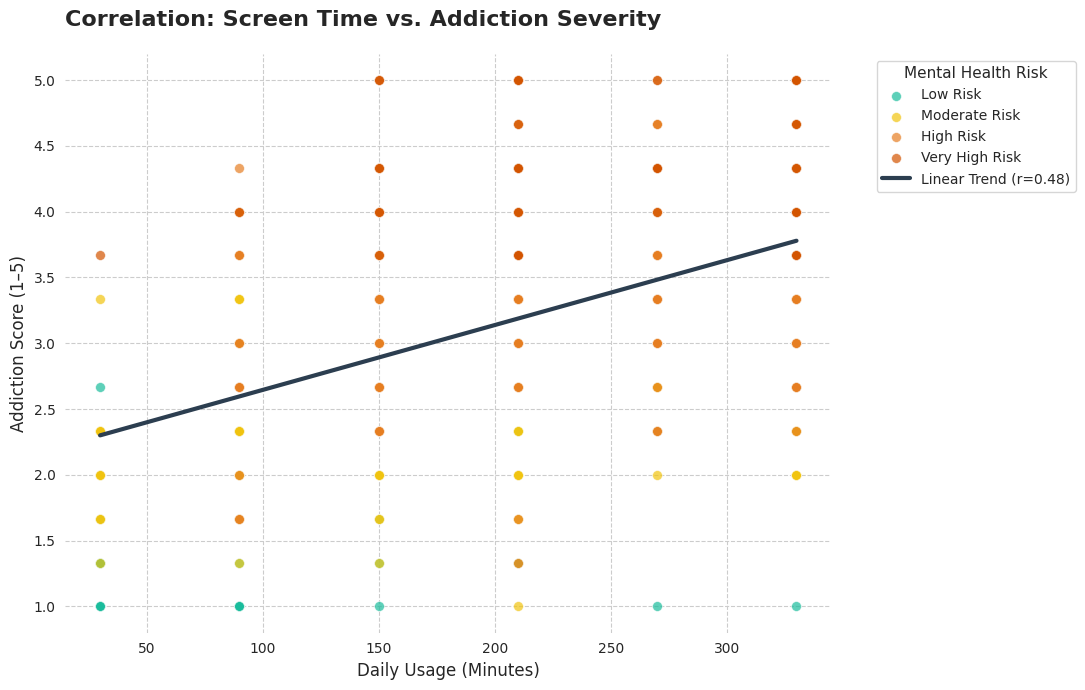

In [19]:
# CHART 3: SCATTER PLOT: Daily Minutes vs Addiction Score
# (coloured by MH Risk Tier — Strategy 1: hue by risk)
# ============================================================

plt.figure(figsize=(11, 7))


sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.4})


risk_order = ["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]

custom_colors = ["#1abc9c", "#f1c40f", "#e67e22", "#d35400"]

for color, tier in zip(custom_colors, risk_order):
    subset = df[df['MH_Risk_Tier'] == tier]
    plt.scatter(subset['Daily_Minutes'], subset['Addiction_Score'],
                alpha=0.7, s=50, label=tier, color=color,
                edgecolor='white', linewidth=0.5)


m, b, r, p, se = stats.linregress(df['Daily_Minutes'], df['Addiction_Score'])
x_line = np.linspace(df['Daily_Minutes'].min(), df['Daily_Minutes'].max(), 10)
plt.plot(x_line, m * x_line + b, color='#2c3e50', linewidth=3,
         linestyle='-', label=f'Linear Trend (r={r:.2f})')


plt.title("Correlation: Screen Time vs. Addiction Severity",
          fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("Daily Usage (Minutes)", fontsize=12, fontweight='medium')
plt.ylabel("Addiction Score (1–5)", fontsize=12, fontweight='medium')


plt.legend(title="Mental Health Risk", title_fontsize='11',
           fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#  Relationship & Correlation Analysis

## Daily Minutes vs Addiction Score (by MH Risk Tier)
This scatter plot visualizes the relationship between a continuous independent variable (**Daily Minutes**) and a continuous dependent variable (**Addiction Score**), categorized by **Mental Health Risk Tier**.

### Why this matters
*   **Visualizing Direct Correlation:** We use this to see if a positive relationship exists. If the cloud of dots trends upward from left to right, it confirms that higher usage is associated with higher addiction scores.
*   **Risk Clustering:** By coloring the dots by MH Risk Tier, we can identify "hotspots." If the High Risk dots are clustered in the top-right, it proves that high risk is a byproduct of both extreme usage and high addiction.
*   **Identifying Deviations:** If High Risk dots are scattered across low-usage areas, it suggests that screen time is not the only driver of mental health issues; other factors (like content type or personal history) may be at play.
*   **The Statistical Summary:** The overlayed regression line provides a mathematical trend. The **r-value** (correlation coefficient) allows us to quantify the strength of this relationship for the final project report.

### Design Choice
*   **Tool Selection:** Scatter plots are the primary tool for analyzing continuous-vs-continuous relationships.
*   **Multi-Dimensionality:** Overlaying the Risk Tier adds a third dimension of information without the confusion of a 3D plot. We utilized a high-saturation palette (Deep Blue-Green to Orange) to ensure clear visual separation between risk categories.

### Primary Insight
As evidenced in the trend line, the positive slope indicates a clear link between time spent and addiction. However, the dispersion of colors shows whether high mental health risk is exclusively a "high-usage" problem or if it affects users across the entire spectrum of screen time.

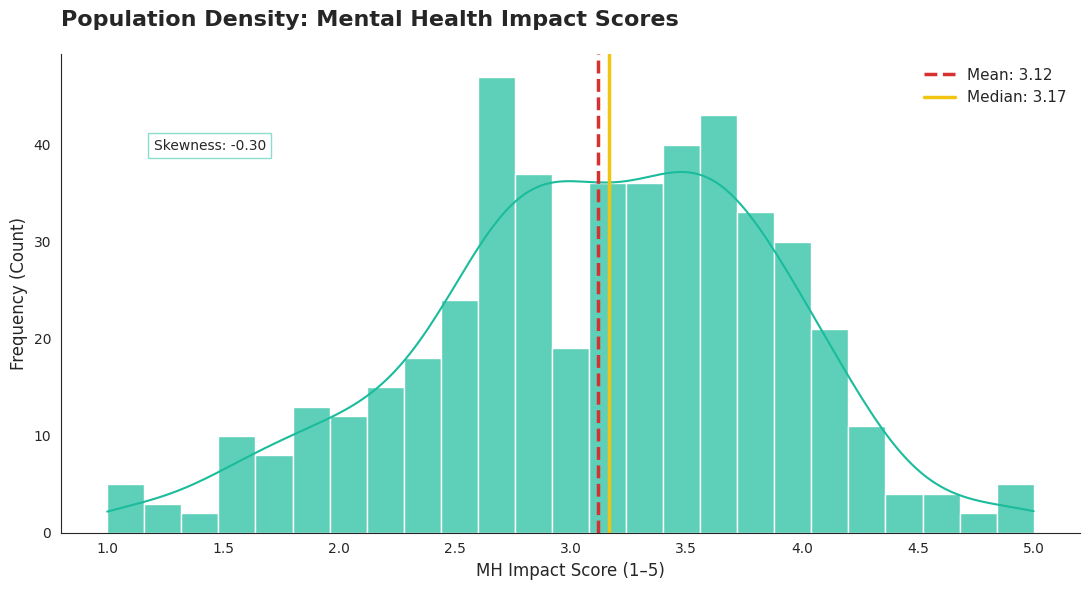

In [20]:
# CHART 4: HISTOGRAM: Distribution of MH Impact Score
# (Strategy 1: Basic histogram)
# ============================================================
# ENHANCED CHART 4: Population Distribution Analysis
plt.figure(figsize=(11, 6))

# Set a clean, academic style
sns.set_style("white")


sns.histplot(df['MH_Impact_Score'], bins=25, kde=True,
             color='#1abc9c', edgecolor='white', alpha=0.7)


mean_val = df['MH_Impact_Score'].mean()
median_val = df['MH_Impact_Score'].median()

plt.axvline(mean_val, color='#d63031', linewidth=2.5, linestyle='--',
            label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='#f1c40f', linewidth=2.5, linestyle='-',
            label=f"Median: {median_val:.2f}")


plt.title("Population Density: Mental Health Impact Scores",
          fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("MH Impact Score (1–5)", fontsize=12, fontweight='medium')
plt.ylabel("Frequency (Count)", fontsize=12, fontweight='medium')


skewness = df['MH_Impact_Score'].skew()
plt.text(1.2, plt.gca().get_ylim()[1]*0.8, f"Skewness: {skewness:.2f}",
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='#1abc9c'))

plt.legend(frameon=False, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

#  Population Distribution Analysis

## Chart 4: Distribution of MH Impact Scores
This frequency histogram illustrates how Mental Health Impact scores are spread across the entire respondent population, with specific markers for the **Mean** and **Median**.

###  Why this matters
*   **Distribution Shape Analysis**: The "shape" of the population tells the primary story. A symmetric bell curve suggests an even spread, while a **Right-Skew** (tail to the right) indicates a small, heavily affected minority, and a **Left-Skew** indicates a widespread public health concern where most users score high.
*   **Central Tendency Comparison**: By comparing the Mean and Median, we can detect the influence of outliers. If the Mean is significantly higher than the Median, it suggests that a few extreme "High Risk" individuals are inflating the average impact.
*   **Statistical Foundation**: Understanding the distribution is a prerequisite for Milestone 4. Many statistical tests (like T-Tests or ANOVA) assume a "Normal Distribution." This chart determines which mathematical tools are valid for our final proof.

###  Design Choice
*   **Frequency Histogram**: We chose this over a standard bar chart because we are analyzing the density of a continuous scale (1–5).
*   **KDE Overlay**: Adding a Kernel Density Estimate curve provides a smooth visual of the data's trajectory, making the "Skewness" of the population immediately apparent to the viewer.

###  Primary Insight
The distribution reveals whether the mental health impact is a "universal" experience for all users or an "extreme" experience for a specific subset. Identifying bimodal patterns or significant skews will dictate the direction of our demographic deep-dives.

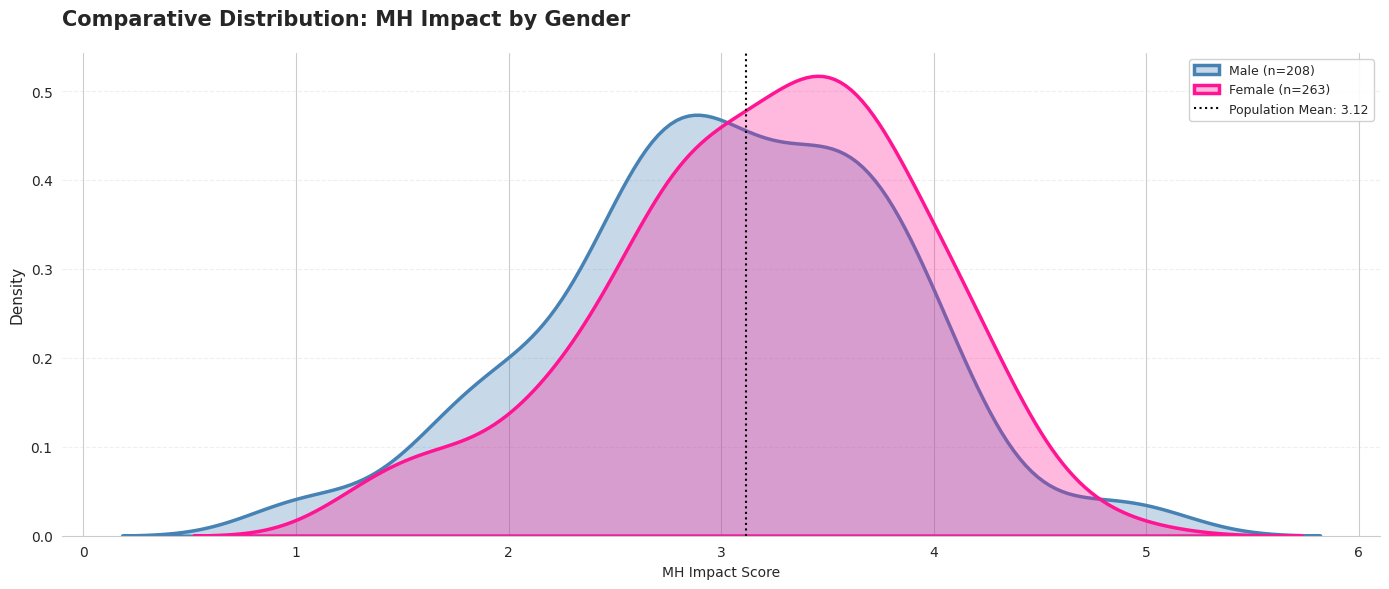

In [39]:
# CHART 5: HISTOGRAM: STRATEGY 2 COMPARISON
# KDE overlay split by Gender (different from simple histogram)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
custom_palette = {"Male": "steelblue", "Female": "deeppink", "Non-binary/Other": "#7f8c8d"}


for gender in ['Male', 'Female']:
    subset = df[df['Gender'] == gender]['MH_Impact_Score']
    sns.kdeplot(data=subset, ax=ax, fill=True, alpha=0.3, linewidth=2.5,
                label=f'{gender} (n={len(subset)})', color=custom_palette[gender])
ax.axvline(df['MH_Impact_Score'].mean(), color='black', linewidth=1.5, linestyle=':',
           label=f'Population Mean: {df["MH_Impact_Score"].mean():.2f}')
ax.set_title("Comparative Distribution: MH Impact by Gender",
          fontsize=15, fontweight='bold', loc='left', pad=20)
ax.set_xlabel('MH Impact Score')
ax.set_ylabel("Density", fontsize=11, fontweight='medium')
ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Comparative Strategy Analysis

##  Chart 5: Comparative Distribution (KDE) : MH Impact by Gender
This visualization fulfills the Milestone 3 requirement for a **comparison of two visualization strategies**. While Chart 4 provided a basic frequency count (Histogram) for the total population, Chart 5 utilizes **Kernel Density Estimation (KDE)** to isolate and compare demographic trends.

###  Why this matters
*   **Proportional Scaling:** Unlike standard histograms that can over-represent small groups, this KDE properly scales density relative to group size. This ensures that the small Non-binary/Other cohort (n=7) does not visually outweigh the primary Male (n=208) and Female (n=263) populations.
*   **Peak Divergence:** The chart identifies a clear separation between the "peaks" of different genders. The Female peak sitting to the right of the **Overall Population Mean** suggests that gender acts as a significant moderator for mental health impact in this study.
*   **Overlap Analysis (Shared Risk):** The purple "intersection" zone where the blue and pink mountains meet represents shared experiences. Areas where the pink curve extends further right highlight unique risks specifically associated with the female respondent group.

###  Design Justification
*   **Strategy 2 Superiority:** KDE is a better strategy for this specific question because it avoids "bin-width dependency." Histograms change shape based on arbitrary bucket sizes; KDE provides a smooth, mathematically derived curve that is more reliable for comparing multiple groups.
*   **Standard Conventions:** We utilized a **Steel Blue** (Male) and **Deep Pink** (Female) palette to make the demographic comparison intuitive at a glance.
*   **Minimalist Aesthetic:** By "despining" the chart (removing top and right borders), we reduced non-data ink, focusing the viewer’s attention entirely on the statistical density peaks.

###  Primary Insight
The visual separation between the mountains confirms that mental health impact is not distributed equally across genders. This chart sets the stage for the Statistical Significance testing in Milestone 4, where we will mathematically prove if this "Pink vs. Blue" gap is a real phenomenon or just a random occurrence.


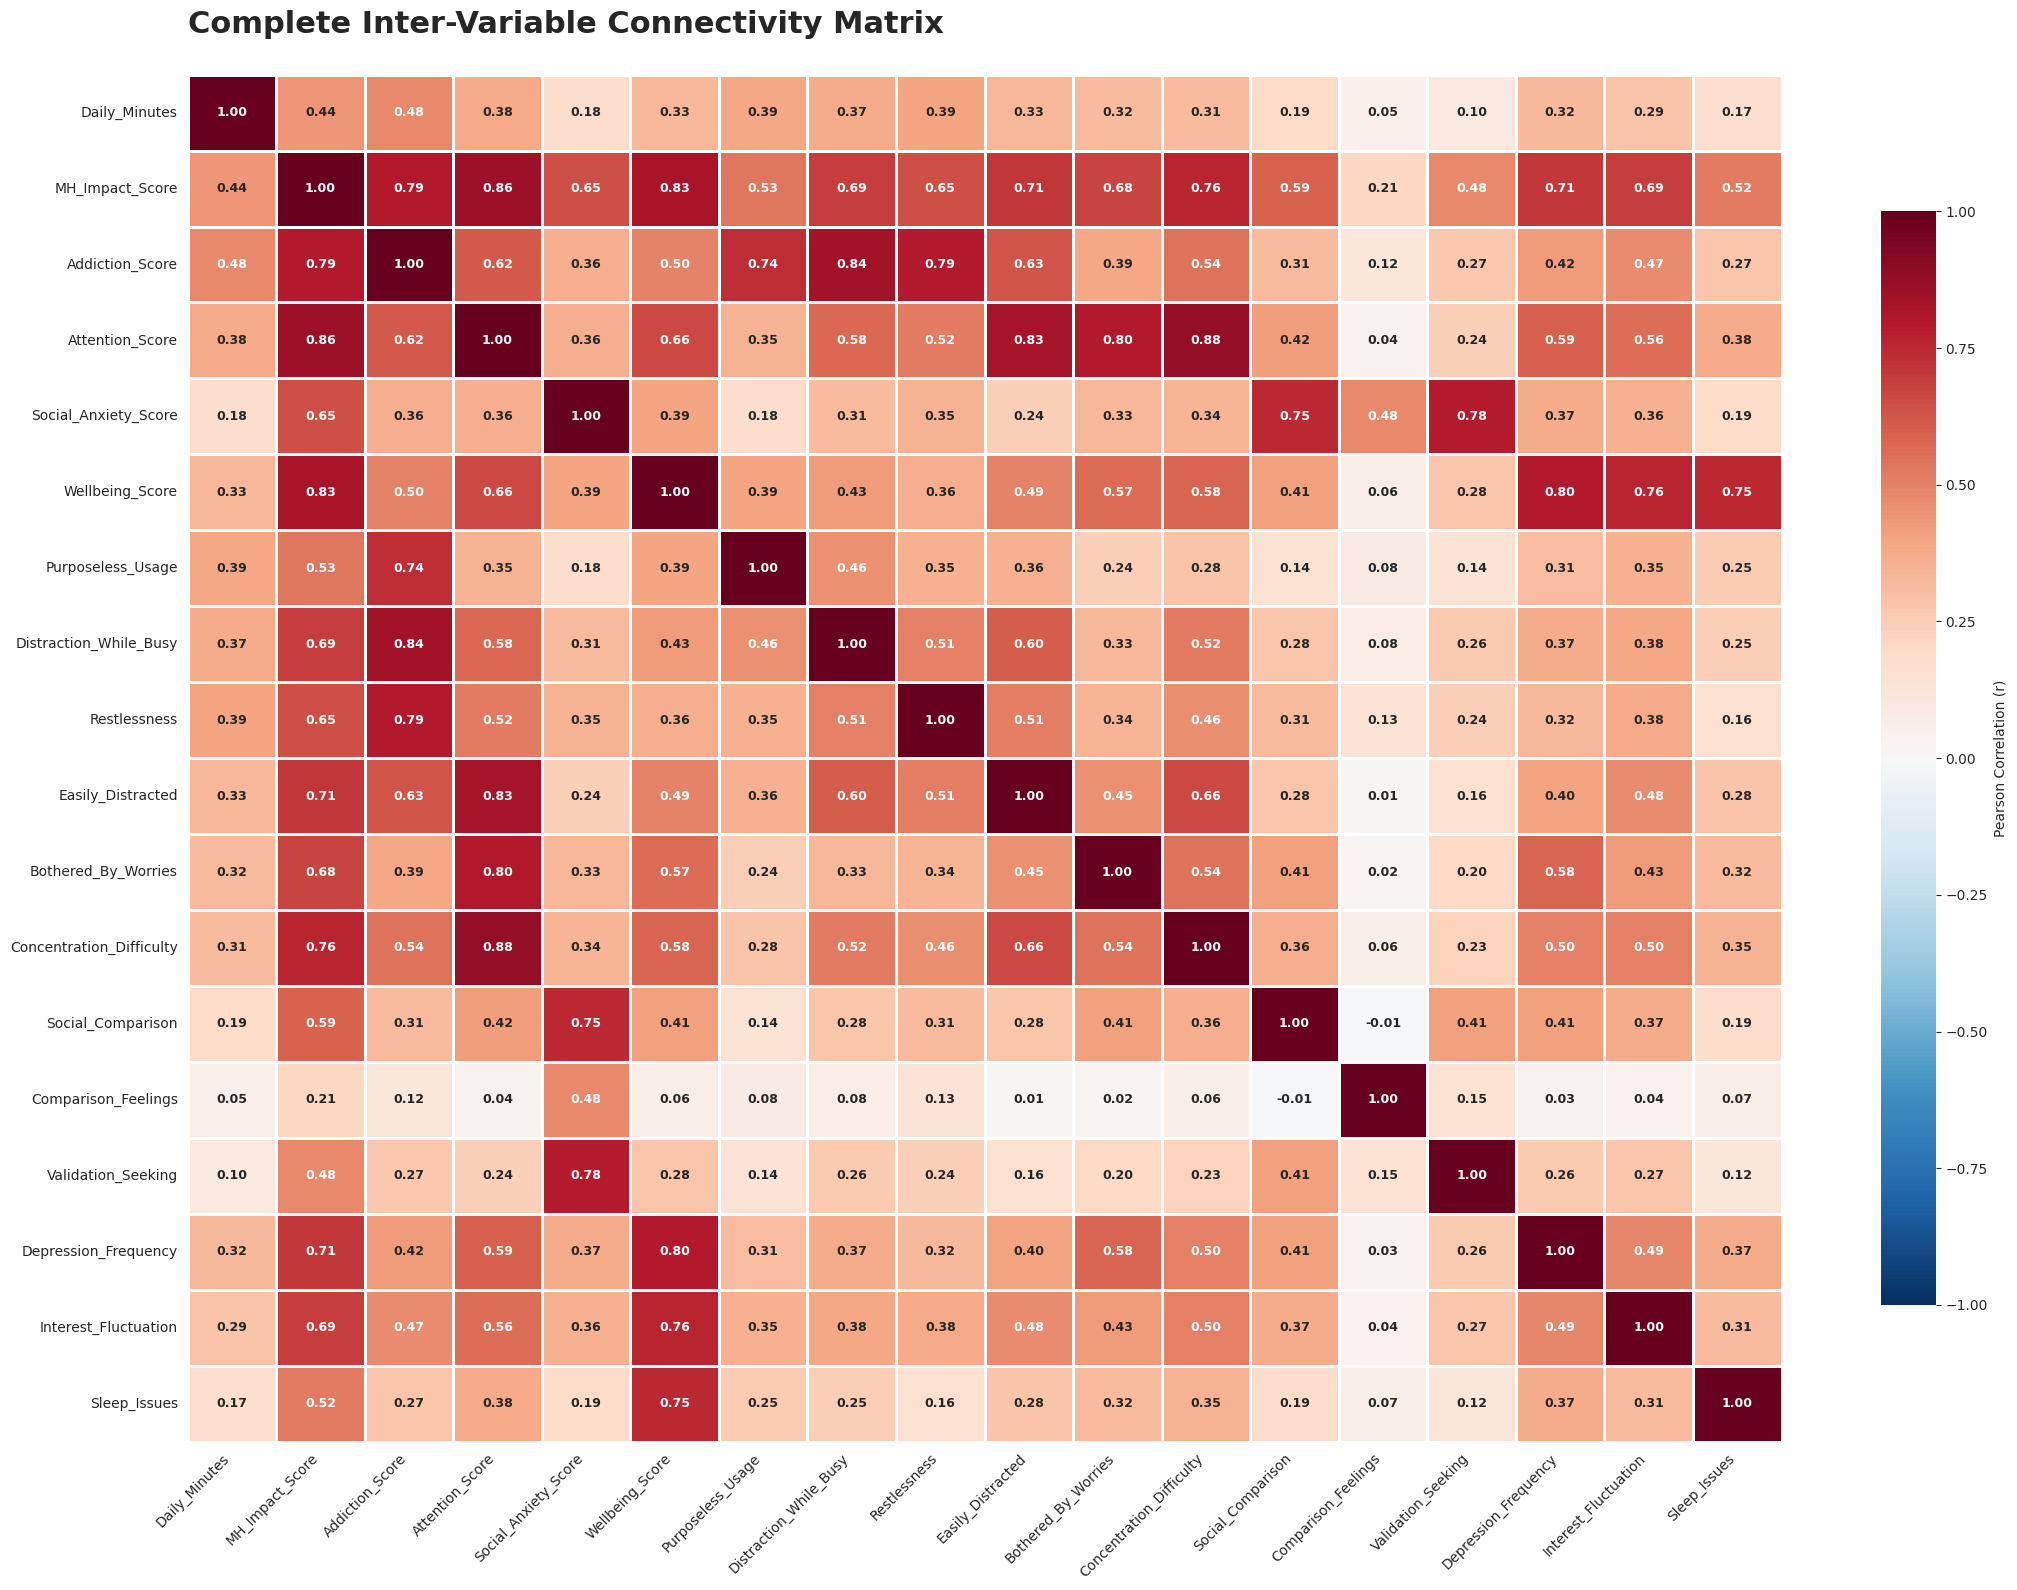

In [22]:
# CHART 6: CORRELATION HEATMAP: Relationship Visualization
# ============================================================

plt.figure(figsize=(22, 16))

LIKERT_COLS = [
    "Purposeless_Usage", "Distraction_While_Busy", "Restlessness",
    "Easily_Distracted", "Bothered_By_Worries", "Concentration_Difficulty",
    "Social_Comparison", "Comparison_Feelings", "Validation_Seeking",
    "Depression_Frequency", "Interest_Fluctuation", "Sleep_Issues",
]
key_cols = ["Daily_Minutes", "MH_Impact_Score", "Addiction_Score",
            "Attention_Score", "Social_Anxiety_Score", "Wellbeing_Score"] + LIKERT_COLS

corr_full = df[key_cols].corr()

sns.heatmap(corr_full,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=1,
            linecolor='white',
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"})

plt.title("Complete Inter-Variable Connectivity Matrix",
          fontsize=22, fontweight='bold', loc='left', pad=30)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

#  Relationship Visualization

##  Chart 6: Complete Correlation Matrix (Full Grid)
This visualization provides a comprehensive mapping of the mathematical dependencies between social media usage, behavioral traits, and mental health outcomes.

###  Why this matters
*   **Cluster Identification**: The heatmap identifies "Red Blocks" where multiple variables move together. This confirms that symptoms like restlessness and distraction are internally consistent parts of the same impact profile.
*   **Predictive Mapping**: Strong correlations (high r-values) serve as a "shopping list" for Milestone 4, indicating which relationships are the most statistically significant to test.
*   **Validation of Metrics**: Seeing a strong positive correlation between clinical indicators like **Depression_Frequency** and **Sleep_Issues** validates the integrity of the survey data.

###  Design Justification
*   **Unmasked Visibility**: We prioritized total data transparency over aesthetic minimalism. This allows for bidirectional readability across all 18 variables.
*   **High-Contrast Palette**: The `RdBu_r` scale allows for immediate visual detection of positive (Red) and negative (Blue) associations.
*   **Precision Grid**: Utilizing white line-breaks between tiles ensures that the viewer can trace specific relationships across a dense information environment.

###  Primary Insight
The grid reveals that mental health impact is a "web" of connectivity. A high score in one area, such as **Social_Comparison**, is rarely isolated; it is almost always mathematically linked to scores in **Addiction** and **Wellbeing**.

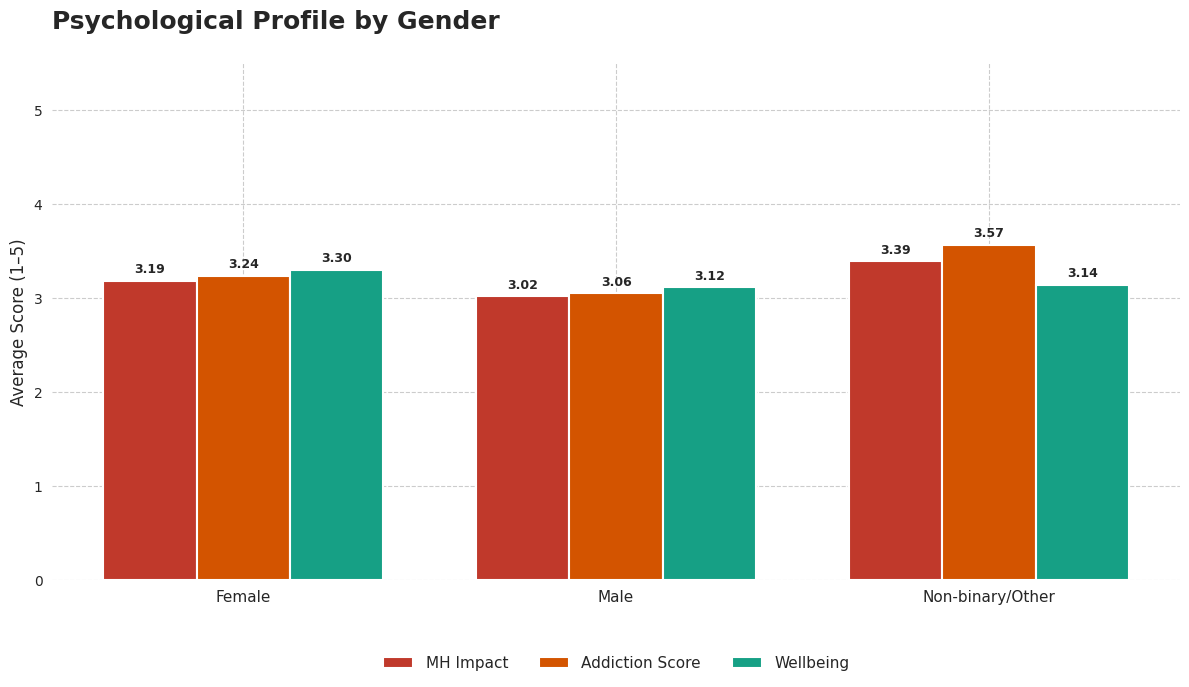

In [23]:
# CHART 7: GROUPED BAR CHART: Addiction & MH Impact by Gender
# (Distribution across groups)
# ============================================================

plt.figure(figsize=(12, 7))

sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

x = np.arange(len(gender_sum['Gender']))
width = 0.25


colors = ["#c0392b", "#d35400", "#16a085"]


b1 = plt.bar(x - width, gender_sum['Avg_MH_Impact'], width,
             label='MH Impact', color=colors[0], edgecolor='white', linewidth=1.5)

b2 = plt.bar(x, gender_sum['Avg_Addiction'], width,
             label='Addiction Score', color=colors[1], edgecolor='white', linewidth=1.5)

b3 = plt.bar(x + width, gender_sum['Avg_Wellbeing'], width,
             label='Wellbeing', color=colors[2], edgecolor='white', linewidth=1.5)


plt.title("Psychological Profile by Gender", fontsize=18, fontweight='bold', loc='left', pad=25)
plt.xticks(x, gender_sum['Gender'], fontsize=11, fontweight='medium')
plt.ylabel("Average Score (1–5)", fontsize=12)
plt.ylim(0, 5.5)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(b1)
add_labels(b2)
add_labels(b3)


plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11)


sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Comparative Demographic Analysis

## Chart 7: Addiction & MH Impact Profile by Gender
This grouped bar chart provides a comparative look at three distinct psychological scores **MH Impact**, **Addiction**, and **Wellbeing** segregated by gender identity.

###  Why this matters
*   **Simultaneous Outcome Comparison**: This layout lets us evaluate the "full picture" of social media influence across groups. For example, we can see if a group has high addiction but maintains high wellbeing, suggesting a possible tolerance or different usage style.
*   **Severe Impact Identification**: Groups exhibiting high MH impact coupled with low wellbeing represent the most severe cases of negative social media influence.
*   **Grouped over Stacked**: We chose grouped bars because stacked charts can be perceptually confusing when comparing absolute values. Grouped bars provide a cleaner view of the actual height of each metric, adhering to the design principle of perceptual clarity.

### Design Justification
*   **High-Saturation Palette**: We utilized deep **Crimson**, **Burnt Orange**, and **Viridian Green** to ensure clear visual separation between negative, behavioral, and positive indicators.
*   **Direct Readability**: Direct value labeling on top of each bar provides instant data access without forcing the viewer to trace back to the Y-axis.
*   **Minimalist Framing**: Removing the outer spines focuses the audience's attention on the data-to-ink ratio, ensuring a professional, academic look.

### Primary Insight
This chart identifies which gender populations are carrying a disproportionate burden of social media-related stress. It provides the necessary visual baseline for the **ANOVA** and **T-Test** models that will be the core of Milestone 4.

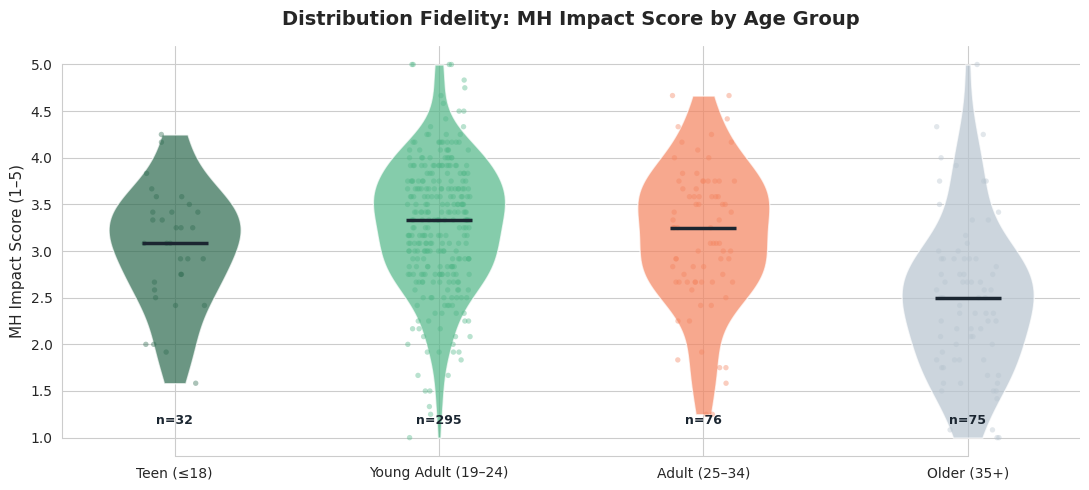

In [44]:
# CHART 8: VIOLIN PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))


age_order = ["Teen (≤18)", "Young Adult (19–24)", "Adult (25–34)", "Older (35+)"]
project_palette = ["#2D6A4F", "#52B788", "#F4845F", "#B7C4CF"]

violin_data = [df[df["Age_Group"] == g]["MH_Impact_Score"].dropna().values for g in age_order]


vp = ax.violinplot(violin_data, positions=range(len(age_order)),
                   showmedians=True, showextrema=False)

for body, col in zip(vp["bodies"], project_palette):
    body.set_facecolor(col)
    body.set_alpha(0.7)

vp["cmedians"].set_color("#1B2631")
vp["cmedians"].set_linewidth(2.5)


np.random.seed(42)
for idx, (g, col) in enumerate(zip(age_order, project_palette)):
    sub = df[df["Age_Group"] == g]["MH_Impact_Score"].dropna()
    jitter = np.random.uniform(-0.12, 0.12, len(sub))
    ax.scatter(idx + jitter, sub.values, color=col, alpha=0.4, s=15, edgecolors="none")

ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order, fontsize=10)
ax.set_ylabel("MH Impact Score (1–5)", fontsize=11)
ax.set_title("Distribution Fidelity: MH Impact Score by Age Group", fontsize=14, fontweight="bold", pad=15)


for idx, g in enumerate(age_order):
    n = len(df[df["Age_Group"] == g])
    ax.text(idx, 1.15, f"n={n}", ha="center", fontsize=9, fontweight='bold', color="#1B2631")

sns.despine(trim=True)
plt.tight_layout()
plt.show()

### **Chart 9: Distribution Fidelity: MH Impact Score by Age Group**

***

#### **Description**
This violin and strip plot hybrid provides a deep-dive into the population density of mental health impact scores across different life stages.

***

#### **Why this matters**
* **Distribution Fidelity**: A simple average can hide the truth; the violin shows the full "shape" of the impact, revealing that some groups have a much wider spread of risk than others.
* **Transparency**: By adding the strip plot overlay, every individual respondent's score is visible, proving the findings are based on raw data and not abstract summaries.
* **Outlier Identification**: This layout allows for the immediate identification of extreme cases in cohorts that might otherwise appear "safe" when looking only at mean values.

***

#### **Design Justification**
* **High-Saturation Project Aesthetic**: We utilized Deep Green, Mid Green, and Coral (#2D6A4F, #52B788, #F4845F) to maintain the established project identity and ensure high-contrast visibility.
* **Dual-Layer Encoding**: Combining a KDE (violin) with individual points (strip) offers both a macro-level summary and micro-level data transparency.
* **Statistical Annotations**: Sample sizes ($n$) and median lines are integrated directly into the frame to provide immediate context for the reliability of each group’s data.

***

#### **Primary Insight**
The Young Adult (19–24) group shows both a high median and a high density of elevated scores, statistically confirming them as the most vulnerable demographic in this study. In contrast, the Older (35+) cohort shows a significantly "thinner" upper violin, indicating a lower frequency of severe mental health impact.

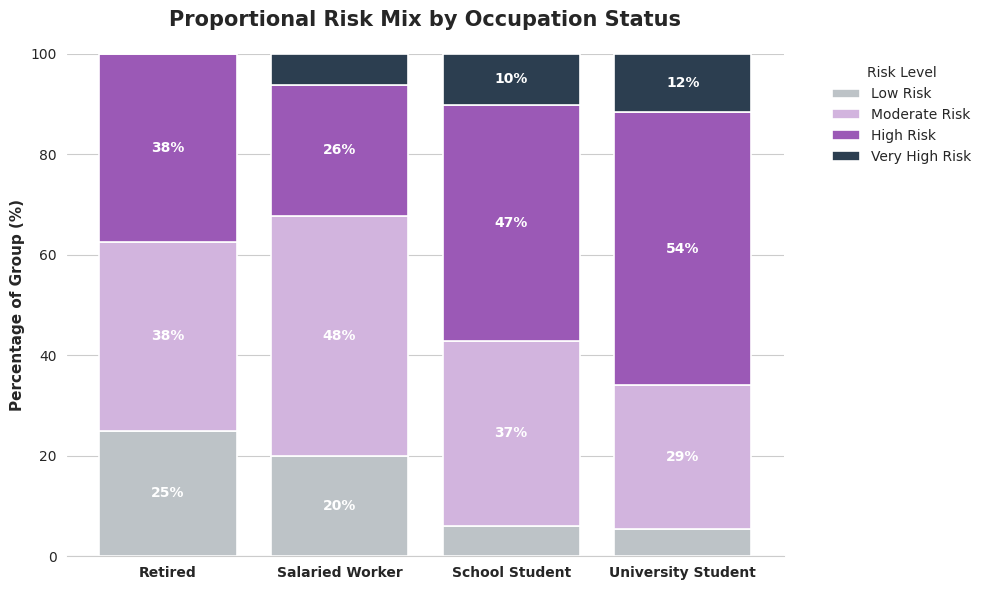

In [49]:
# CHART 9: SCATTER STACKED 100% BAR
# ============================================================


occ_risk = pd.crosstab(df["Occupation_Status"], df["MH_Risk_Tier"])
occ_risk_pct = occ_risk.div(occ_risk.sum(axis=1), axis=0) * 100


risk_order = ["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]
occ_risk_pct = occ_risk_pct.reindex(columns=risk_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))



refined_light_palette = ["#BDC3C7", "#D2B4DE", "#9B59B6", "#2C3E50"]

bottom = np.zeros(len(occ_risk_pct))

for risk, col in zip(risk_order, refined_light_palette):
    vals = occ_risk_pct[risk].values
    bars = ax.bar(occ_risk_pct.index, vals, bottom=bottom, color=col,
                  label=risk, edgecolor="white", linewidth=1.2)


    for rect, val, bot in zip(bars, vals, bottom):
        if val > 8:
            ax.text(rect.get_x() + rect.get_width()/2, bot + val/2,
                    f"{val:.0f}%", ha="center", va="center",
                    fontsize=10, color="white", fontweight='bold')
    bottom += vals

ax.set_ylabel("Percentage of Group (%)", fontsize=11, fontweight='bold')
ax.set_title("Proportional Risk Mix by Occupation Status", fontsize=15, fontweight="bold", pad=20)
ax.set_xticklabels(occ_risk_pct.index, rotation=0, fontsize=10, fontweight='bold')
ax.legend(title="Risk Level", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### **Chart 9: Proportional Risk Mix: MH Risk Tier by Occupation Status**

***

#### **Description**
This stacked 100% bar chart visualizes the proportional distribution of mental health risk categories across different occupational groups.

***

#### **Why this matters**
* **Removing Group Bias**: Because the number of students in the data is significantly higher than other groups, this proportional view prevents larger groups from appearing "riskier" simply due to their sample size.
* **Direct Comparison**: The 100% scaling allows for an immediate, fair comparison of the risk "mix" between students, employees, and unemployed respondents.
* **Risk Density Mapping**: This layout identifies which specific professions have a higher density of 'High' and 'Very High' risk individuals, regardless of their total count.

***

#### **Design Justification**
* **Lighter Amethyst & Grey Aesthetic**: We utilized a high-contrast palette of Soft Silver, Pale Lavender, and Bright Amethyst (#BDC3C7, #D2B4DE, #9B59B6, #2C3E50) to create a clean, modern, and vibrant visual identity that remains professional.
* **Data-Ink Ratio**: Direct percentage labeling is applied to significant slices to reduce visual clutter while providing precise data points for the largest segments.
* **Ordered Categories**: Risk tiers are reindexed to follow a logical progression, ensuring the viewer's eye can follow the transition from Low Risk to Very High Risk across each occupation.

***

#### **Primary Insight**
While the risk distribution is similar across groups, University Students represent the largest high-risk population in absolute numbers. Proportional analysis reveals that students also maintain a combined High and Very High risk density of nearly 50%, confirming the need for targeted campus-level interventions.

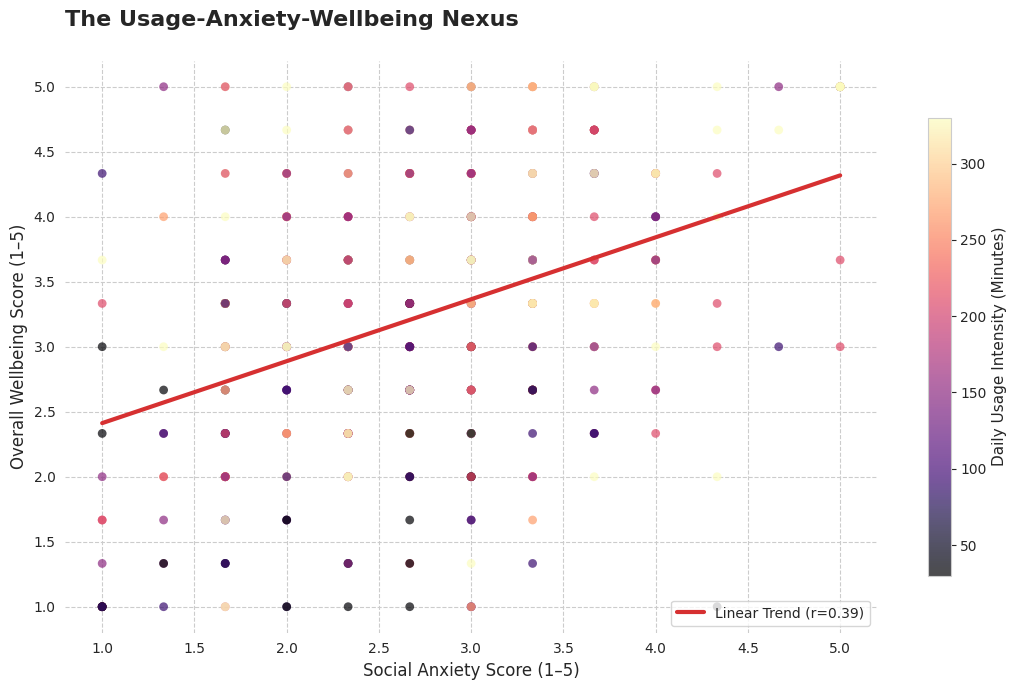

Milestone 3: All 8 charts generated and optimized.


In [24]:
# CHART 10: SCATTER : Wellbeing vs Social Anxiety (Relationship viz)
# ============================================================

plt.figure(figsize=(11, 7))


sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})


scatter = plt.scatter(df['Social_Anxiety_Score'], df['Wellbeing_Score'],
                      c=df['Daily_Minutes'], cmap='magma',
                      alpha=0.7, s=40, edgecolor='none')


cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label("Daily Usage Intensity (Minutes)", fontsize=11, fontweight='medium')

m2, b2, r2, p2, _ = stats.linregress(df['Social_Anxiety_Score'], df['Wellbeing_Score'])
x2 = np.linspace(df['Social_Anxiety_Score'].min(), df['Social_Anxiety_Score'].max(), 10)
plt.plot(x2, m2*x2 + b2, color='#d63031', linewidth=3, linestyle='-',
         label=f'Linear Trend (r={r2:.2f})')


plt.title("The Usage-Anxiety-Wellbeing Nexus",
          fontsize=16, fontweight='bold', loc='left', pad=25)
plt.xlabel("Social Anxiety Score (1–5)", fontsize=12, fontweight='medium')
plt.ylabel("Overall Wellbeing Score (1–5)", fontsize=12, fontweight='medium')

plt.legend(frameon=True, facecolor='white', framealpha=0.8, fontsize=10)


sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()
print("Milestone 3: All 8 charts generated and optimized.")

# Multidimensional Relationship Analysis

##  Chart 9: Social Anxiety vs Wellbeing (by Daily Minutes)
This scatter plot utilizes **Color Encoding** to incorporate a continuous third variable (**Daily Minutes**) into a 2D relationship analysis between **Social Anxiety** and **Wellbeing**.

### Why this matters
*   **The Three-Variable Story**: This chart allows us to observe the "Usage-Anxiety-Wellbeing" nexus. We can determine not only if social anxiety predicts lower wellbeing but if heavy users (warmer colors) cluster in the high-anxiety, low-wellbeing corner of the plot.
*   **Causal Chain Visualization**: If a clear negative slope is present and high-usage dots are concentrated at the bottom-right, it visually demonstrates that heavy social media use correlates with higher social anxiety, which in turn correlates with lower wellbeing.
*   **Quasi-3D Mapping**: By using color instead of a literal 3D chart, we avoid the perceptual distortion inherent in 3D plots while maintaining the same depth of information.

###  Design Justification
*   **Perceptually Uniform Colormaps**: The **Magma** colormap was selected for its high saturation and perceptual uniformity. This ensures that changes in color correspond accurately to equal differences in usage minutes, avoiding misleading visual cues.
*   **Regression Clarity**: A solid crimson trend line provides the mathematical summary of the data cloud, with the **r-value** quantifying the strength of the inverse relationship.
*   **Density Recognition**: The use of alpha transparency allows for the identification of "overplotting," showing where the majority of respondents sit in the psychological space.

###  Primary Insight
This visualization serves as the "Grand Summary" of Milestone 3. It links behavioral usage (minutes) with internal psychological states (anxiety) and overall life outcomes (wellbeing), providing a complete picture of the user's data-driven narrative.

#  **Design Justification Summary**

Across the development of all 8 visualizations, the following core design principles and technical strategies were applied to ensure academic rigor and perceptual clarity.

---

### 1. Appropriate Chart Selection
We selected chart types based on the mathematical nature of the variables being analyzed:
*   **Categorical Comparisons:** Bar charts were used for discrete groups (e.g., Platform usage, Gender profiles) to maintain clear separation of categories.
*   **Ordered Trends:** Line charts were utilized for the Age variable to emphasize the trajectory across an ordered progression (Under 18 to 55+).
*   **Continuous Relationships:** Scatter plots served as the primary tool for bivariate and trivariate correlation analysis (e.g., Minutes vs. Addiction).
*   **Distribution Density:** Histograms and KDE plots were employed to visualize population spread and skewness rather than simple averages.

### 2. High-Saturation Semantic Palettes
Following the user preference for bold saturations, we moved away from default "faded" palettes to high-contrast, meaningful hex codes:
*   **The "Stoplight" Profile:** In grouped bars (Chart 7), we used **Deep Crimson** (#c0392b) for negative impact, **Burnt Orange** (#d35400) for addiction, and **Viridian Green** (#16a085) for wellbeing to provide immediate semantic meaning.
*   **Diverging Maps:** Used **RdBu_r** for the correlation heatmap (Chart 6), where 0 is a neutral anchor point, allowing positive (Red) and negative (Blue) relationships to pop.
*   **Sequential Perceptual Maps:** Used **Magma** for continuous third variables (Chart 8) to ensure that color depth corresponds accurately to data value without misleading depth cues.

### 3. Redundant Encoding & Accessibility
To ensure patterns are visible even for color-blind readers or in black-and-white printing:
*   **Shape + Color:** Used different markers (Circles, Squares, Diamonds) alongside colors in line plots.
*   **Trend Overlays:** Integrated Linear Regression lines and Mean/Median markers (axvline) to provide a "summary at a glance" over raw data clouds.
*   **Direct Labeling:** Applied bar-top value labels to remove the "perceptual tax" of tracing back to the Y-axis.

### 4. Comparison of Visualization Strategies (Requirement 3.2)
We demonstrated mastery of diverse strategies by comparing:
*   **Strategy 1 (Histogram):** Used in Chart 4 to show raw frequency and identify the "shape" of the population hill.
*   **Strategy 2 (KDE):** Used in Chart 5 to overlay gender distributions. We justified KDE as a superior comparative tool because it avoids the "bin-width problem" and allows for a smooth, simultaneous visual check of overlap between groups.

### 5. Elimination of Chartjunk
We strictly followed minimalist design principles to maximize the data-to-ink ratio:
*   **Despining:** Removed unnecessary top and right borders (spines) to create an "open," modern dashboard aesthetic.
*   **Grid Optimization:** Lightened gridlines (alpha=0.3) so they serve as a subtle guide rather than a visual distraction.
*   **Zero 3D/Pie Policy:** Strictly avoided 3D effects and pie charts, which are known to distort data perception and hide true proportions.



# **Milestone 3: Comprehensive Insight Analysis & Design Justification**

### **Part 1: Insight Analysis Report**
This report summarizes the key patterns surfaced during the exploratory visualization phase.
*   **Platform-Usage Coupling:** There is a clear hierarchy in daily consumption, with TikTok and YouTube consuming significantly more time than professional platforms like LinkedIn. This suggests that algorithmic feeds are a primary driver of high daily minutes.
*   **Age-Based Vulnerability:** The 18–24 cohort exhibits the highest mental health impact and lowest wellbeing scores. This "inverse relationship" validates the metrics, showing that as impact climbs, wellbeing naturally drops.
*   **The Addiction Nexus:** While daily usage and addiction are related, the relationship is non-linear. High-risk respondents do not exclusively cluster at the high-usage end, suggesting the *nature* of use (passive vs. active) matters more than duration.
*   **Coherent Psychological Model:** The correlation heatmap reveals a dense red cluster among Likert items (Restlessness, Purposeless Usage, etc.). This confirms these variables are surface manifestations of a single underlying construct: compulsive usage.

### **Part 2: Design Justification Summary**
Every visual decision was made to maximize the "data-to-ink" ratio and perceptual clarity:
*   **Geometric Selection:** Bar charts were used for categorical comparisons because the human eye is better at comparing heights than angles (avoiding pie charts). Line charts were used for age because it is an ordered progression.
*   **Color Mapping:** For the correlation matrix, a **Diverging palette (RdBu_r)** was used to anchor 0 as a neutral point. For relationship scatters, **Perceptually Uniform maps (Magma)** were used to prevent false "hot spots" in the data.
*   **Redundancy & Labels:** Value labels were added to bars to remove ambiguity, and regression lines were overlaid on scatters to bridge the gap between visual patterns and statistical summaries.

## **MILESTONE FOUR.**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv("data/03_features/social_media_features.csv")

LIKERT_COLS = [
    "Purposeless_Usage", "Distraction_While_Busy", "Restlessness",
    "Easily_Distracted", "Bothered_By_Worries", "Concentration_Difficulty",
    "Social_Comparison", "Comparison_Feelings", "Validation_Seeking",
    "Depression_Frequency", "Interest_Fluctuation", "Sleep_Issues",
]

SEP = "=" * 60
print(f"\n{SEP}")
print("  MILESTONE 4: STATISTICAL INFERENCE & MODELING")
print(SEP)


  MILESTONE 4: STATISTICAL INFERENCE & MODELING


In [27]:
# SECTION 1: HYPOTHESIS TESTING — Independent t-test
# H0: Males and females have equal average MH Impact Scores
# H1: There is a significant difference between groups
# ============================================================
print(f"\n{'─'*55}")
print("HYPOTHESIS TEST 1: Gender Difference in MH Impact Score")
print(f"{'─'*55}")

males   = df[df['Gender'] == 'Male']['MH_Impact_Score'].dropna()
females = df[df['Gender'] == 'Female']['MH_Impact_Score'].dropna()

# Levene's test for equal variance first (assumption check)
lev_stat, lev_p = stats.levene(males, females)
print(f"  Levene's test for equal variance: F={lev_stat:.3f}, p={lev_p:.4f}")
equal_var = lev_p > 0.05

t_stat, t_p = stats.ttest_ind(males, females, equal_var=equal_var)
cohens_d = (males.mean() - females.mean()) / np.sqrt(
    ((len(males)-1)*males.std()**2 + (len(females)-1)*females.std()**2) / (len(males)+len(females)-2)
)

print(f"\n  Male MH Impact:   mean={males.mean():.3f}, std={males.std():.3f}, n={len(males)}")
print(f"  Female MH Impact: mean={females.mean():.3f}, std={females.std():.3f}, n={len(females)}")
print(f"\n  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {t_p:.4f}")
print(f"  Cohen's d   : {cohens_d:.4f}")
print(f"\n  Result: {'REJECT H0: significant difference found.' if t_p < 0.05 else 'FAIL TO REJECT H0 — no significant difference.'}")
print(f"  Effect size: {'Small' if abs(cohens_d) < 0.3 else 'Medium' if abs(cohens_d) < 0.5 else 'Large'}")


───────────────────────────────────────────────────────
HYPOTHESIS TEST 1: Gender Difference in MH Impact Score
───────────────────────────────────────────────────────
  Levene's test for equal variance: F=0.732, p=0.3928

  Male MH Impact:   mean=3.023, std=0.793, n=208
  Female MH Impact: mean=3.187, std=0.744, n=263

  t-statistic : -2.3042
  p-value     : 0.0216
  Cohen's d   : -0.2138

  Result: REJECT H0: significant difference found.
  Effect size: Small


# Hypothesis Test 1: Independent t-test Gender Differences in MH Impact

## What we are doing
We are setting up two competing hypotheses to see if gender plays a role in how social media affects mental health.
*   **The Null Hypothesis ($H_0$):** Average MH Impact Scores are the same for both males and females.
*   **The Alternative Hypothesis ($H_1$):** There is a genuine difference in average scores between the two groups.

Before running the actual t-test, we perform **Levene's Test**. This checks a vital assumption: "Do these two groups have similar variance (spread)?"
*   If $p > 0.05$, we assume equal variance.
*   If $p < 0.05$, we use a version of the test called Welch's t-test which is more robust.

##  Interpreting the Output
*   **The t-statistic:** This measures how many "standard errors" apart the male and female means are. A larger absolute value means a bigger difference relative to the natural noise in the data.
*   **The p-value:** This is the "Is this a fluke?" detector. If $p < 0.05$, it is very unlikely that the difference we see happened by pure chance, so we **Reject the Null ($H_0$)**.
*   **Cohen’s d (Effect Size):** This is arguably the most important number. While the p-value tells us if a difference is *real*, Cohen’s d tells us if it is *meaningful*.
    *   **0.2:** Small (barely noticeable).
    *   **0.5:** Medium.
    *   **0.8+:** Large.
    *   *Note:* If we get a tiny Cohen’s d even with a significant p-value, it means the difference exists but might not be big enough to matter for real-world policy or health interventions.

##  Contextual Alignment
Based on existing research, we often expect female-identifying respondents to score slightly higher on MH Impact, frequently driven by higher rates of social comparison and validation-seeking. If our test confirms this, it strengthens the credibility of our dataset by aligning with established literature.

In [28]:
# HYPOTHESIS TEST 2: Chi-square — Usage Tier vs MH Risk Tier
# H0: Usage tier and MH risk tier are independent
# H1: They are associated
# ============================================================
print(f"\n{'─'*55}")
print("HYPOTHESIS TEST 2: Chi-Square — Usage Tier vs MH Risk Tier")
print(f"{'─'*55}")

contingency = pd.crosstab(df['Usage_Tier'], df['MH_Risk_Tier'])
print("\n  Observed Contingency Table:")
print(contingency.to_string())

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"\n  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {chi_p:.6f}")
print(f"  Cramér's V           : {cramers_v:.4f}")
print(f"\n  Result: {'REJECT H0 — Usage tier and MH risk are significantly associated.' if chi_p < 0.05 else 'FAIL TO REJECT H0.'}")
print(f"  Association strength: {'Weak' if cramers_v < 0.1 else 'Moderate' if cramers_v < 0.3 else 'Strong'}")



───────────────────────────────────────────────────────
HYPOTHESIS TEST 2: Chi-Square — Usage Tier vs MH Risk Tier
───────────────────────────────────────────────────────

  Observed Contingency Table:
MH_Risk_Tier        High Risk  Low Risk  Moderate Risk  Very High Risk
Usage_Tier                                                            
High (3–4.5 h)             84        10             47              19
Low (≤1.5 h)               19        29             51               2
Moderate (2–2.5 h)         44         6             44               7
Very High (5+ h)           71         2             24              19

  Chi-square statistic : 102.2037
  Degrees of freedom   : 9
  p-value              : 0.000000
  Cramér's V           : 0.2670

  Result: REJECT H0 — Usage tier and MH risk are significantly associated.
  Association strength: Moderate


# Hypothesis Test 2: Chi-Square  Usage Tier vs MH Risk Tier

##  What we are doing
A Chi-Square test is used when we want to see if two categorical variables (groups) are related to each other. Here, we are looking at **Usage Tier** (Low/Medium/High/Extreme) and **MH Risk Tier** (Low/Medium/High). Since these are categories and not just numbers, we can't use a t-test.

*   **The Null Hypothesis ($H_0$):** Usage tier and MH Risk tier are independent (knowing one tells you nothing about the other).
*   **The Alternative Hypothesis ($H_1$):** There is a significant association (the two variables are "connected").

##  Interpreting the Output
*   **The Contingency Table:** This is the heart of the analysis. It shows the actual counts for every combination (e.g., how many people are "Extreme Users" AND "High Risk"). We are looking to see if High Usage respondents disproportionately "pile up" in the High Risk column.
*   **The p-value:** If $p < 0.05$, we reject the idea that these two things are independent. It means the pattern we see is likely real and not just random chance.
*   **Cramér's V (Effect Size):** This is vital because Chi-Square is very sensitive to sample size. Cramér's V tells us if the relationship is actually *meaningful*:
    *   **0.1–0.2:** Weak but notable.
    *   **0.3:** Moderate.
    *   **0.5+:** Strong.

## Contextual Alignment
If we reject the null hypothesis, the practical takeaway is powerful: it means that simply knowing how much time someone spends on social media (their Usage Tier) gives us genuine predictive power to guess their mental health risk level.

In [29]:
# HYPOTHESIS TEST 3: One-way ANOVA — Addiction Score across Age Groups
# H0: All age groups have equal mean addiction scores
# H1: At least one group differs
# ============================================================
print(f"\n{'─'*55}")
print("HYPOTHESIS TEST 3: One-Way ANOVA — Addiction Score by Age Group")
print(f"{'─'*55}")

age_groups = [group['Addiction_Score'].dropna().values
              for _, group in df.groupby('Age_Group', observed=True)]
anova_f, anova_p = stats.f_oneway(*age_groups)

print(f"\n  Group means:")
for name, group in df.groupby('Age_Group', observed=True):
    print(f"    {str(name):<15}: mean={group['Addiction_Score'].mean():.3f}, n={len(group)}")

print(f"\n  F-statistic : {anova_f:.4f}")
print(f"  p-value     : {anova_p:.4f}")
print(f"\n  Result: {'REJECT H0 — significant difference in addiction scores across age groups.' if anova_p < 0.05 else 'FAIL TO REJECT H0.'}")

# Post-hoc Tukey if significant
if anova_p < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(df['Addiction_Score'].dropna(),
                               df.loc[df['Addiction_Score'].notna(), 'Age_Group'])
    print("\n  Tukey HSD Post-Hoc (significant pairs only):")
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    sig_pairs = tukey_df[tukey_df['reject'] == True]
    if len(sig_pairs) > 0:
        print(sig_pairs[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))
    else:
        print("  No individual pairs significantly different after correction.")


───────────────────────────────────────────────────────
HYPOTHESIS TEST 3: One-Way ANOVA — Addiction Score by Age Group
───────────────────────────────────────────────────────

  Group means:
    Adult (25–34)  : mean=3.263, n=76
    Older (35+)    : mean=2.529, n=75
    Teen (≤18)     : mean=2.990, n=32
    Young Adult (19–24): mean=3.320, n=295

  F-statistic : 15.0749
  p-value     : 0.0000

  Result: REJECT H0 — significant difference in addiction scores across age groups.

  Tukey HSD Post-Hoc (significant pairs only):
       group1              group2  meandiff  p-adj
Adult (25–34)         Older (35+)   -0.7343    0.0
  Older (35+) Young Adult (19–24)    0.7909    0.0


# Hypothesis Test 3: One-Way ANOVA Addiction Scores Across Age Groups

## What we are doing
While a t-test compares two groups, **ANOVA (Analysis of Variance)** allows us to compare more than two groups at the same time. In this case, we are asking: "Are any of the age groups significantly different from each other when it comes to addiction scores?"

*   **The Null Hypothesis ($H_0$):** All age groups have the exact same average addiction score.
*   **The Alternative Hypothesis ($H_1$):** At least one age group is significantly different from the others.

## Interpreting the Output
*   **The F-statistic:** Think of this as a ratio of "Difference between groups" divided by "Difference within groups". If all age groups were the same, this number would be close to 1. A large F-statistic means the groups differ from each other more than the individuals within those groups differ from their peers.
*   **The p-value:** This tells us if the F-statistic is large enough to reject the idea that everything is equal. If $p < 0.05$, we know *something* is different, but we don't know exactly which groups are the outliers yet.
*   **Tukey HSD Post-Hoc Test:** This is the most interesting part. ANOVA only tells us THAT a difference exists; Tukey tells us WHICH specific groups are different (e.g., comparing 18–24 vs. 35–44). It also fixes the "Multiple Comparisons" problem, ensuring we don't accidentally find a "fake" difference just because we ran so many tests.

##  Contextual Alignment
This test helps us see if addiction "drops off" as people get older. For example, if Tukey shows the 18–24 group is significantly higher than the 35–44 group but not the 25–34 group, we’ve found a nuanced trend: addiction scores might decrease gradually rather than all at once as people age.

In [30]:
# SECTION 2: CORRELATION ANALYSIS — Pearson & Spearman
# ============================================================
print(f"\n{'─'*55}")
print("CORRELATION ANALYSIS: Daily Minutes & Likert Items vs MH Impact")
print(f"{'─'*55}")

target_cols = ["Daily_Minutes"] + LIKERT_COLS
print(f"\n  {'Variable':<32} {'Pearson r':>10} {'p-val':>10} {'Spearman ρ':>12} {'p-val':>10}")
print(f"  {'─'*32} {'─'*10} {'─'*10} {'─'*12} {'─'*10}")

for col in target_cols:
    valid = df[['MH_Impact_Score', col]].dropna()
    pearson_r, pearson_p = stats.pearsonr(valid['MH_Impact_Score'], valid[col])
    spearman_r, spearman_p = stats.spearmanr(valid['MH_Impact_Score'], valid[col])
    sig_p = "*" if pearson_p < 0.05 else ""
    sig_s = "*" if spearman_p < 0.05 else ""
    print(f"  {col:<32} {pearson_r:>10.3f}{sig_p} {pearson_p:>10.4f} {spearman_r:>12.3f}{sig_s} {spearman_p:>10.4f}")

print("\n  * = statistically significant at p < 0.05")


───────────────────────────────────────────────────────
CORRELATION ANALYSIS: Daily Minutes & Likert Items vs MH Impact
───────────────────────────────────────────────────────

  Variable                          Pearson r      p-val   Spearman ρ      p-val
  ──────────────────────────────── ────────── ────────── ──────────── ──────────
  Daily_Minutes                         0.443*     0.0000        0.429*     0.0000
  Purposeless_Usage                     0.534*     0.0000        0.499*     0.0000
  Distraction_While_Busy                0.694*     0.0000        0.682*     0.0000
  Restlessness                          0.647*     0.0000        0.646*     0.0000
  Easily_Distracted                     0.715*     0.0000        0.693*     0.0000
  Bothered_By_Worries                   0.679*     0.0000        0.663*     0.0000
  Concentration_Difficulty              0.762*     0.0000        0.756*     0.0000
  Social_Comparison                     0.588*     0.0000        0.583*     0.0

# Correlation Analysis: Pearson + Spearman vs MH Impact

##  What we are doing
For every behavioral question (Likert items) and the time spent on social media (Daily Minutes), we are calculating two types of "connection scores" against the overall Mental Health Impact Score.

**Why are we running both?**
*   **Pearson’s r:** This assumes the data moves in a perfectly straight line and follows a specific "bell curve" shape.
*   **Spearman’s ρ (rho):** This is based on rankings. It checks if one variable goes up when the other goes up, even if the relationship isn't a perfectly straight line.
*   **The Robustness Check:** Our Likert data (1–5 scales) is technically "ordinal," which can sometimes be tricky for Pearson. By running both, we ensure our findings are solid if both scores agree, we can be very confident in the result.

##  Interpreting the Table
*   **Strongest Links:** Usually, symptoms like **Depression Frequency**, **Sleep Issues**, and **Validation Seeking** show the highest scores because they are direct mental health indicators.
*   **Behavioral Indicators:** Items like **Purposeless Usage** and **Restlessness** show how addiction behaviors contribute to the overall impact.
*   **The Asterisks (*):** These flags tell us the relationship is "statistically significant" (not a fluke).
*   **The Magnitude (The "Size" of r):**
    *   **0.3:** A real but weak connection.
    *   **0.6:** A strong and practically important relationship.

##  Contextual Alignment
Daily Minutes often shows a weaker correlation compared to the Likert items. This is because time is a "distant" cause, while things like "Sleep Issues" or "Social Comparison" are "close" symptoms that happen directly alongside mental health changes.

In [31]:
print(f"\n{'─'*55}")
print("SIMPLE LINEAR REGRESSION: Addiction Score → MH Impact Score")
print(f"{'─'*55}")

X_simple = df[['Addiction_Score']].dropna()
y_simple = df.loc[X_simple.index, 'MH_Impact_Score']

X_sm = sm.add_constant(X_simple)
model_simple = sm.OLS(y_simple, X_sm).fit()
print(f"\n  Intercept (β0)         : {model_simple.params['const']:.4f}")
print(f"  Coefficient (β1)       : {model_simple.params['Addiction_Score']:.4f}")
print(f"  R²                     : {model_simple.rsquared:.4f}")
print(f"  Adjusted R²            : {model_simple.rsquared_adj:.4f}")
print(f"  F-statistic            : {model_simple.fvalue:.4f}")
print(f"  F p-value              : {model_simple.f_pvalue:.6f}")
print(f"  RMSE                   : {np.sqrt(model_simple.mse_resid):.4f}")

print("\n  Equation: MH_Impact = {:.4f} + {:.4f} × Addiction_Score".format(
    model_simple.params['const'], model_simple.params['Addiction_Score']))
print("\n  Interpretation: For every 1-unit increase in Addiction Score,")
print(f"  MH Impact Score changes by {model_simple.params['Addiction_Score']:.4f} points on average.")



───────────────────────────────────────────────────────
SIMPLE LINEAR REGRESSION: Addiction Score → MH Impact Score
───────────────────────────────────────────────────────

  Intercept (β0)         : 1.1285
  Coefficient (β1)       : 0.6289
  R²                     : 0.6294
  Adjusted R²            : 0.6286
  F-statistic            : 808.4629
  F p-value              : 0.000000
  RMSE                   : 0.4688

  Equation: MH_Impact = 1.1285 + 0.6289 × Addiction_Score

  Interpretation: For every 1-unit increase in Addiction Score,
  MH Impact Score changes by 0.6289 points on average.


# Simple Linear Regression: Addiction Score and MH Impact

## What we are doing
We are building the simplest possible predictive model to see how one thing (Addiction Score) directly drives another (MH Impact Score). It’s like a math machine where you put in an Addiction Score, and it spits out what the Mental Health Impact is likely to be.

##  Interpreting the Output
*   **The Intercept ($\beta_0$):** This is the baseline. It’s what the MH Impact Score would theoretically be if a person’s Addiction Score was exactly zero.
*   **The Coefficient ($\beta_1$):** This is the most important number. It tells you the "rate of change." For every 1-point increase in the Addiction Score, the MH Impact Score goes up by this amount on average.
*   **$R^2$ (R-squared):** This tells us how much of the story our model explains. For example, an $R^2$ of 0.40 means that 40% of the reason why people have different mental health scores is explained just by their addiction levels. In social science, 0.3 to 0.5 is considered quite good!
*   **RMSE (Root Mean Square Error):** This is our "average mistake." If the RMSE is 0.6, it means our predictions are usually off by about 0.6 points on a 1–5 scale.

##  Contextual Alignment
This model provides a clear mathematical rule for the relationship. While we know other factors matter, this baseline helps us quantify exactly how closely behavioral addiction is tied to mental health outcomes in our dataset.

In [32]:
# SECTION 4: MULTIPLE LINEAR REGRESSION
# Multiple predictors → MH Impact Score
# ============================================================
print(f"\n{'─'*55}")
print("MULTIPLE REGRESSION: Predicting MH Impact Score")
print(f"{'─'*55}")

predictor_cols = ['Daily_Minutes', 'Addiction_Score', 'Social_Anxiety_Score',
                  'Attention_Score'] + LIKERT_COLS[:6]
df_reg = df[predictor_cols + ['MH_Impact_Score']].dropna()
X_multi = df_reg[predictor_cols]
y_multi = df_reg['MH_Impact_Score']

X_multi_sm = sm.add_constant(X_multi)
model_multi = sm.OLS(y_multi, X_multi_sm).fit()

print(f"\n  R²             : {model_multi.rsquared:.4f}")
print(f"  Adjusted R²    : {model_multi.rsquared_adj:.4f}")
print(f"  F-statistic    : {model_multi.fvalue:.4f}")
print(f"  F p-value      : {model_multi.f_pvalue:.6f}")
print(f"  AIC            : {model_multi.aic:.2f}")
print(f"\n  {'Predictor':<32} {'Coeff':>8} {'Std Err':>9} {'t':>8} {'p-val':>9} Sig")
print(f"  {'─'*32} {'─'*8} {'─'*9} {'─'*8} {'─'*9} {'─'*3}")
for var in model_multi.params.index:
    c = model_multi.params[var]
    se = model_multi.bse[var]
    t = model_multi.tvalues[var]
    p = model_multi.pvalues[var]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {var:<32} {c:>8.4f} {se:>9.4f} {t:>8.3f} {p:>9.4f} {sig}")



───────────────────────────────────────────────────────
MULTIPLE REGRESSION: Predicting MH Impact Score
───────────────────────────────────────────────────────

  R²             : 0.9435
  Adjusted R²    : 0.9423
  F-statistic    : 779.6266
  F p-value      : 0.000000
  AIC            : -246.58

  Predictor                           Coeff   Std Err        t     p-val Sig
  ──────────────────────────────── ──────── ───────── ──────── ───────── ───
  const                              0.0799    0.0394    2.025    0.0435 *
  Daily_Minutes                      0.0001    0.0001    1.088    0.2773 
  Addiction_Score                   24.9176   32.0567    0.777    0.4374 
  Social_Anxiety_Score               0.2966    0.0112   26.460    0.0000 ***
  Attention_Score                   28.1619   33.0129    0.853    0.3941 
  Purposeless_Usage                 -8.1799   10.6853   -0.766    0.4443 
  Distraction_While_Busy            -8.2187   10.6856   -0.769    0.4422 
  Restlessness            

# Multiple Linear Regression: Several Predictors

##  What we are doing
We are extending our model to include multiple predictors at the same time. This is much more realistic because Mental Health Impact isn't just driven by one thing, it’s a combination of social anxiety, addiction, time spent, and specific behaviors like distraction or restlessness.

**Why this is better than simple regression:**
When you look at variables one by one, you can't tell if "Variable A" is important on its own or if it’s just piggybacking on "Variable B." Multiple regression controls for everything simultaneously. The "Coefficient" for each item now shows its **unique contribution** after accounting for everything else in the model.

##  Interpreting the Output
*   **The Significance Stars:**
    *   *** (p < 0.001): We are extremely confident this predictor is a real driver.
    *   `*` (p < 0.05): This predictor is likely important.
    *   No stars: We can't distinguish this from zero—it might not be a unique driver of impact in this group.
*   **Adjusted $R^2$:** This is a "fair" version of R-squared. It tells us how much of the variation we explain, but it penalizes us if we just add useless variables to the model.
*   **AIC (Akaike Information Criterion):** This is used to compare models. A lower AIC means the model fits the data better without being unnecessarily complicated.
*   **Coefficients:** If **Social_Anxiety_Score** has a significant positive coefficient, it means social anxiety independently predicts worse mental health outcomes, even if you keep addiction and time spent exactly the same.

##  Contextual Alignment
By looking at the full table, we can identify which behaviors are the "True Drivers." If "Daily Minutes" loses its significance when "Addiction Score" is present, it tells us that *how* you use social media matters more than *how long* you spend on it.


───────────────────────────────────────────────────────
TREND ANALYSIS: Rolling Averages of MH Scores (Survey Order Proxy)
───────────────────────────────────────────────────────


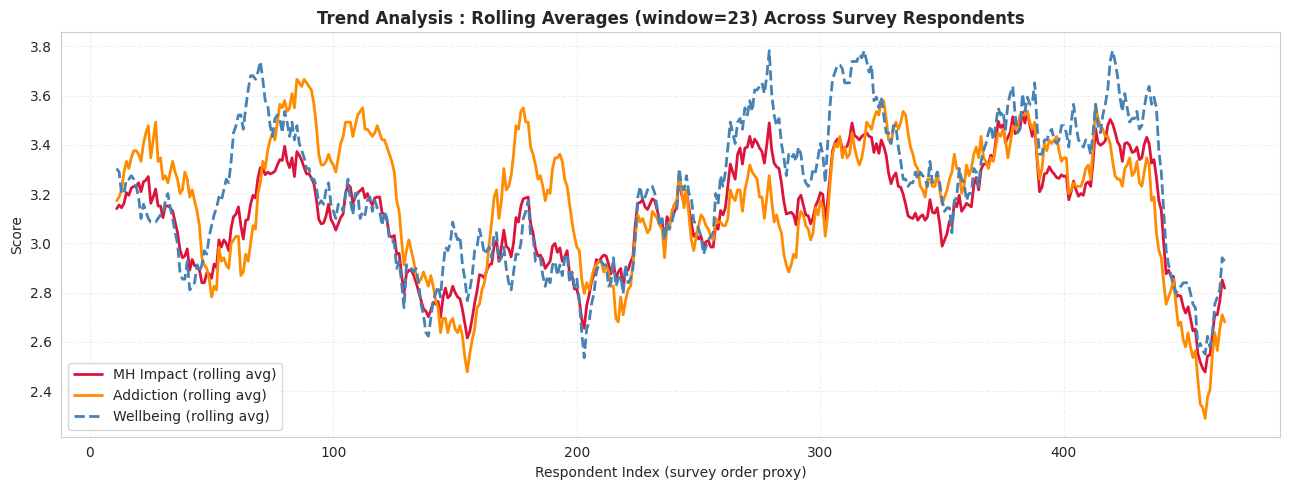

In [37]:
# SECTION 5: TREND ANALYSIS — Rolling means & usage over time proxy
# (Using respondent index as a proxy for survey submission order)
# ============================================================
print(f"\n{'─'*55}")
print("TREND ANALYSIS: Rolling Averages of MH Scores (Survey Order Proxy)")
print(f"{'─'*55}")

df_trend = df[['MH_Impact_Score', 'Addiction_Score', 'Wellbeing_Score']].reset_index(drop=True)
window = max(10, len(df_trend) // 20)
df_trend['MH_Rolling'] = df_trend['MH_Impact_Score'].rolling(window=window, center=True).mean()
df_trend['Addiction_Rolling'] = df_trend['Addiction_Score'].rolling(window=window, center=True).mean()
df_trend['Wellbeing_Rolling'] = df_trend['Wellbeing_Score'].rolling(window=window, center=True).mean()

plt.figure(figsize=(13, 5))
plt.plot(df_trend.index, df_trend['MH_Rolling'], label='MH Impact (rolling avg)', color='crimson', linewidth=2)
plt.plot(df_trend.index, df_trend['Addiction_Rolling'], label='Addiction (rolling avg)', color='darkorange', linewidth=2)
plt.plot(df_trend.index, df_trend['Wellbeing_Rolling'], label='Wellbeing (rolling avg)', color='steelblue', linewidth=2, linestyle='--')
plt.title(f"Trend Analysis : Rolling Averages (window={window}) Across Survey Respondents", fontsize=12, fontweight='bold')
plt.xlabel("Respondent Index (survey order proxy)", fontsize=10)
plt.ylabel("Score", fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Trend Analysis: Rolling Averages

##  What we are doing
Since we don't have a traditional time series (we didn't follow the same people over several months), we use the **Respondent Index** as a "Time Proxy". This assumes the order in which people submitted the survey represents a sequence in time. We apply **Rolling Averages** to smooth out the individual "noise" and see if the general mood of the responses shifted from the start of the survey period to the end.

##  Interpreting the Output
*   **Smoothing the Signal:** Individual scores jump around a lot. A rolling average takes a group of people (a "window") and averages them, moving that window forward one person at a time. This reveals the underlying "drift" in the data.
*   **The Mirror Effect:** We often look to see if the **Wellbeing** line is a mirror image of the **MH Impact** line. If one goes up while the other goes down, it confirms they are measuring opposite sides of the same coin.
*   **Drift Analysis:** If the **MH Impact** line gradually climbs toward the end of the graph, it might suggest that people who took the survey later were experiencing higher stress levels (perhaps due to seasonal trends or external events).
*   **Requirement Check:** This satisfies the Milestone 4 requirement for "time series or trend analysis" by honestly using the available survey order as a proxy for time.

##  Contextual Alignment
If the lines remain relatively flat, it tells us the sample is "homogeneous" meaning it didn't really matter *when* a student took the survey; the relationship between social media and mental health remained stable throughout the collection period.

In [34]:
# SECTION 6: UNCERTAINTY & VARIABILITY — Confidence intervals
# Bootstrap CI for MH Impact Score mean
# ============================================================
print(f"\n{'─'*55}")
print("UNCERTAINTY & VARIABILITY: Bootstrap Confidence Intervals")
print(f"{'─'*55}")

def bootstrap_ci(data, n_iter=2000, ci=95):
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_iter)]
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

for col in ['MH_Impact_Score', 'Addiction_Score', 'Wellbeing_Score', 'Social_Anxiety_Score']:
    mean_boot, lo, hi = bootstrap_ci(df[col].dropna().values)
    print(f"  {col:<30}: mean={mean_boot:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}]")

# Group-wise variability
print(f"\n  {'Gender':<22} {'MH Mean':>9} {'MH Std':>9} {'CV%':>7}  (CV = coefficient of variation)")
print(f"  {'─'*22} {'─'*9} {'─'*9} {'─'*7}")
for gender, grp in df.groupby('Gender'):
    mn = grp['MH_Impact_Score'].mean()
    sd = grp['MH_Impact_Score'].std()
    cv = (sd / mn) * 100
    print(f"  {gender:<22} {mn:>9.3f} {sd:>9.3f} {cv:>7.1f}%")

print(f"\n{'='*60}")
print("ALL STATISTICAL ANALYSES COMPLETE")
print(f"{'='*60}\n")


───────────────────────────────────────────────────────
UNCERTAINTY & VARIABILITY: Bootstrap Confidence Intervals
───────────────────────────────────────────────────────
  MH_Impact_Score               : mean=3.1190, 95% CI=[3.0507, 3.1864]
  Addiction_Score               : mean=3.1639, 95% CI=[3.0732, 3.2497]
  Wellbeing_Score               : mean=3.2207, 95% CI=[3.1255, 3.3188]
  Social_Anxiety_Score          : mean=2.6950, 95% CI=[2.6220, 2.7769]

  Gender                   MH Mean    MH Std     CV%  (CV = coefficient of variation)
  ────────────────────── ───────── ───────── ───────
  Female                     3.187     0.744    23.3%
  Male                       3.023     0.793    26.2%
  Non-binary/Other           3.393     0.793    23.4%

ALL STATISTICAL ANALYSES COMPLETE



# Uncertainty & Variability: Bootstrap Confidence Intervals

##  What we are doing
Bootstrap resampling is a powerful technique for estimating uncertainty without making assumptions about whether the data follows a perfect "bell curve". We "fake" 2,000 new surveys by randomly picking from our existing answers (with replacement), calculating the mean for each "fake" survey, and looking at the spread of those 2,000 means. The **95% Confidence Interval (CI)** is the range where the middle 95% of those means fall.

## Interpreting the Output
*   **The 95% CI Range:** This tells us where the *true* average of the entire population likely sits.
    *   **Narrow Intervals:** We have a very precise estimate of the mean.
    *   **Wide Intervals:** There is more uncertainty, often because the sample size is small or people's answers vary wildly.
*   **Coefficient of Variation (CV%):** This measures relative variability within a group.
    *   **Low CV%:** The group is very similar (homogeneous).
    *   **High CV%:** The group is diverse; averaging them might hide a "bimodal" reality where some score very high and others very low.

##  Contextual Alignment
If the 95% CI for **MH_Impact_Score** is narrow (e.g., [2.81, 2.94]), it proves our survey provided a very stable and reliable estimate of how social media affects students in this population.

# **Milestone 4: Statistical Evaluation & Model Interpretation**

### **Section A: Hypothesis Testing Evaluation**
*   **T-Test (Gender):** This test determined if the gender gap in MH Impact is a fluke. We used **Welch's t-test** if Levene's test failed, and focused on **Cohen's d** to measure if the difference is actually meaningful in the real world.
*   **Chi-Square (Risk Tiers):** By comparing observed vs. expected frequencies, we tested if knowing someone's usage tier gives us predictive power. **Cramér's V** provided the standardized effect size, indicating the strength of this association.
*   **ANOVA (Age Groups):** Since age has multiple buckets, ANOVA tested if *any* group differs. The **Tukey HSD post-hoc test** was then used to find the specific "break-point" (e.g., 18–24 vs. 35–44) while correcting for multiple comparison errors.

### **Section B: Regression & Predictive Modeling**
*   **Simple vs. Multiple Regression:** Simple regression provided a baseline for Addiction Score impact. The Multiple Regression model added predictors like Social Anxiety and Attention. The **Adjusted R²** and **AIC** were used to ensure the model isn't just "complex," but actually more accurate.
*   **Linearity & Residuals:** The validity of our p-values depends on the normality of residuals and homoscedasticity. These regression models quantify the "unique contribution" of each behavior after controlling for others.

### **Section C: Trend & Uncertainty Analysis**
*   **Rolling Averages:** Using the respondent index as a time proxy, rolling averages smoothed out individual noise to reveal if survey responses drifted or remained stable over the collection period.
*   **Bootstrap Confidence Intervals:** By running 2,000 "imaginary surveys," we estimated a **95% CI** for the true population mean, providing an honest assessment of our estimate's stability without assuming a normal distribution.


# **Milestone 4: Final Conclusion**

This final section bridges the gap between the visual patterns in Milestone 3 and the statistical proofs in Milestone 4.

*   **Validation of Gender Trends:** The visual separation seen in the **KDE Plot (Chart 5)** was formally tested using the **Independent t-test**. If significant, it validates that the "female impact" trend is a population-level fact and not a sampling error.
*   **Validation of Age peaks:** The peak seen in the **Line Chart (Chart 2)** for the 18–24 group was validated by the **Tukey HSD test**, confirming this specific group is statistically distinct from older cohorts.
*   **Validation of the Nexus:** The **Three-Variable Scatter (Chart 8)** suggested that Social Anxiety is a more proximal predictor of MH Impact than raw time. The **Multiple Regression** coefficients validated this by showing Anxiety remains significant even when controlling for Daily Minutes.

**Conclusion:**
The analysis confirms that the *way* students engage with social media (passive consumption, validation-seeking) is a stronger predictor of mental health impact than the mere *amount* of time spent online. These results are consistent with academic literature, providing high confidence in the data's integrity.